<a href="https://colab.research.google.com/github/SammyGbabs/Soil-invertebrate-vibroacoustic-cnn/blob/main/Notebook_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## V3 Exploration: Understand the new data folder structure

Before inventorying, walk both season folders to understand:
- The directory structure of the new data vs old data
- Where config files live
- Rough file counts

This is read-only exploration — no processing, no writing.

In [ ]:
# Mount the Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path

DRIVE_ROOT = Path('/content/drive/MyDrive')
SEASON1_ROOT = DRIVE_ROOT / 'Invertebrate recordings subset'
SEASON2_ROOT = DRIVE_ROOT / 'Invertebrate recordings new'

print("=" * 70)
print("Checking both season folders exist")
print("=" * 70)
print(f"Season 1 exists: {SEASON1_ROOT.exists()}  ({SEASON1_ROOT})")
print(f"Season 2 exists: {SEASON2_ROOT.exists()}  ({SEASON2_ROOT})")
print()

def explore_tree(root, max_depth=3, max_items_per_level=8):
    """Print folder structure up to max_depth, limiting items shown per level."""
    root = Path(root)
    if not root.exists():
        print(f"  (does not exist: {root})")
        return

    def _walk(path, depth, prefix=""):
        if depth > max_depth:
            return
        try:
            entries = sorted(path.iterdir())
        except Exception as e:
            print(f"{prefix}  [error reading: {e}]")
            return

        dirs = [e for e in entries if e.is_dir()]
        files = [e for e in entries if e.is_file()]

        # Show directories
        for d in dirs[:max_items_per_level]:
            print(f"{prefix}📁 {d.name}/")
            _walk(d, depth + 1, prefix + "   ")
        if len(dirs) > max_items_per_level:
            print(f"{prefix}   ... and {len(dirs) - max_items_per_level} more folders")

        # Show sample files at this level
        wav_files = [f for f in files if f.suffix.upper() == '.WAV']
        other_files = [f for f in files if f.suffix.upper() != '.WAV']

        if wav_files:
            print(f"{prefix}   [{len(wav_files)} .WAV files, e.g. {wav_files[0].name}]")
        for f in other_files[:max_items_per_level]:
            print(f"{prefix}📄 {f.name}")

    _walk(root, 0)

print("=" * 70)
print("SEASON 1 structure (old data)")
print("=" * 70)
explore_tree(SEASON1_ROOT, max_depth=3)
print()

print("=" * 70)
print("SEASON 2 structure (new data)")
print("=" * 70)
explore_tree(SEASON2_ROOT, max_depth=4)  # deeper for new data since we don't know it
print()

# =============================================================================
# Look for config files specifically
# =============================================================================
print("=" * 70)
print("Searching for config/settings files in both seasons")
print("=" * 70)

def find_config_files(root, limit=20):
    root = Path(root)
    if not root.exists():
        return []
    configs = []
    for pattern in ['*.txt', '*.TXT', '*CONFIG*', '*config*', '*.csv']:
        configs.extend(root.rglob(pattern))
    return configs[:limit]

print("Season 1 config-like files:")
s1_configs = find_config_files(SEASON1_ROOT)
for c in s1_configs[:10]:
    print(f"  {c.relative_to(SEASON1_ROOT)}")
print(f"  (total found: {len(s1_configs)})")
print()

print("Season 2 config-like files:")
s2_configs = find_config_files(SEASON2_ROOT)
for c in s2_configs[:10]:
    print(f"  {c.relative_to(SEASON2_ROOT)}")
print(f"  (total found: {len(s2_configs)})")
print()

# =============================================================================
# Rough file counts
# =============================================================================
print("=" * 70)
print("Rough .WAV file counts")
print("=" * 70)
s1_wavs = list(SEASON1_ROOT.rglob('*.WAV')) if SEASON1_ROOT.exists() else []
s2_wavs = list(SEASON2_ROOT.rglob('*.WAV')) if SEASON2_ROOT.exists() else []
print(f"Season 1: {len(s1_wavs)} .WAV files")
print(f"Season 2: {len(s2_wavs)} .WAV files")

Checking both season folders exist
Season 1 exists: True  (/content/drive/MyDrive/Invertebrate recordings subset)
Season 2 exists: True  (/content/drive/MyDrive/Invertebrate recordings new)

SEASON 1 structure (old data)
📁 Day 1/
   📁 Batch 1/
      📁 1 beetle larvae/
            [26 .WAV files, e.g. 20240730_063313.WAV]
      📁 10 ants/
            [25 .WAV files, e.g. 20240730_063337.WAV]
      📁 3 beetle larvae/
            [26 .WAV files, e.g. 20240730_063328.WAV]
   📁 Batch 2/
      📁 1 beetle larvae/
            [27 .WAV files, e.g. 20240730_084000.WAV]
      📁 10 ants/
            [27 .WAV files, e.g. 20240730_084500.WAV]
      📁 Control/
            [26 .WAV files, e.g. 20240730_084515.WAV]
   📁 Batch 3/
      📁 10 termites/
            [25 .WAV files, e.g. 20240730_105742.WAV]
         📄 CONFIG.TXT
      📁 3 beetle larvae/
            [25 .WAV files, e.g. 20240730_110000.WAV]
      📁 30 termites/
            [26 .WAV files, e.g. 20240730_105819.WAV]
   📁 Batch 4/
      📁 1 bee

In [ ]:
# =============================================================================
# 1. Read a season 1 and season 2 CONFIG.TXT to compare firmware/settings
# =============================================================================
print("=" * 70)
print("CONFIG comparison: Season 1 vs Season 2")
print("=" * 70)

s1_config = SEASON1_ROOT / 'Day 1/Batch 3/10 termites/CONFIG.TXT'
s2_config = SEASON2_ROOT / 'Day 1/Batch 4/30 ants/CONFIG.TXT'

for label, cfg in [('SEASON 1', s1_config), ('SEASON 2', s2_config)]:
    print(f"\n--- {label}: {cfg.relative_to(cfg.parents[4])} ---")
    if cfg.exists():
        print(cfg.read_text())
    else:
        print("  (not found)")

# =============================================================================
# 2. Investigate the suspicious 2024-dated files in Season 2 controls
# =============================================================================
print("=" * 70)
print("Investigating suspicious control folders in Season 2 Day 1 Batch 3")
print("=" * 70)

suspect_folders = [
    SEASON2_ROOT / 'Day 1/Batch 3/Control',
    SEASON2_ROOT / 'Day 1/Batch 3/Control (2)',
]

for folder in suspect_folders:
    print(f"\n--- {folder.name} ---")
    if not folder.exists():
        print("  (folder not found)")
        continue
    wavs = sorted(folder.glob('*.WAV'))
    print(f"  {len(wavs)} .WAV files")
    # Show first and last few filenames to see the date pattern
    for w in wavs[:3]:
        print(f"    {w.name}")
    if len(wavs) > 6:
        print("    ...")
    for w in wavs[-3:]:
        print(f"    {w.name}")
    # Count how many are 2024 vs 2025 dated (by filename prefix)
    y2024 = sum(1 for w in wavs if w.name.startswith('2024'))
    y2025 = sum(1 for w in wavs if w.name.startswith('2025'))
    other = len(wavs) - y2024 - y2025
    print(f"  Filename date prefixes: 2024={y2024}, 2025={y2025}, other={other}")

# =============================================================================
# 3. Cross-check: do those exact filenames exist in Season 1?
# =============================================================================
print()
print("=" * 70)
print("Cross-check: do the 2024-dated season-2 control files exist in season 1?")
print("=" * 70)

# Grab a couple of the 2024-named files from season 2 controls
sample_2024_names = []
for folder in suspect_folders:
    if folder.exists():
        for w in sorted(folder.glob('*.WAV')):
            if w.name.startswith('2024'):
                sample_2024_names.append(w.name)

sample_2024_names = sample_2024_names[:5]
print(f"Checking {len(sample_2024_names)} sample 2024-named files against all of season 1...")

# Build a set of all season 1 filenames
s1_all_names = {p.name for p in SEASON1_ROOT.rglob('*.WAV')}
for name in sample_2024_names:
    in_s1 = name in s1_all_names
    print(f"  {name}: {'FOUND in season 1' if in_s1 else 'not in season 1'}")

# =============================================================================
# 4. Compare file-header timestamps vs filename for a couple of files
# =============================================================================
print()
print("=" * 70)
print("Header vs filename timestamp check (using soundfile metadata)")
print("=" * 70)
try:
    import soundfile as sf
    check_files = []
    # one clearly-2025 season 2 file
    d1b4 = SEASON2_ROOT / 'Day 1/Batch 4/30 ants'
    if d1b4.exists():
        w = sorted(d1b4.glob('*.WAV'))
        if w:
            check_files.append(w[0])
    # one suspicious 2024 file
    if sample_2024_names:
        for folder in suspect_folders:
            cand = folder / sample_2024_names[0]
            if cand.exists():
                check_files.append(cand)
                break

    for f in check_files:
        info = sf.info(str(f))
        print(f"  {f.name}")
        print(f"    samplerate={info.samplerate}, frames={info.frames}, "
              f"duration={info.duration:.1f}s, subtype={info.subtype}")
except Exception as e:
    print(f"  (soundfile check skipped: {e})")

CONFIG comparison: Season 1 vs Season 2

--- SEASON 1: Invertebrate recordings subset/Day 1/Batch 3/10 termites/CONFIG.TXT ---
Device ID                       : 248D9B026037251D
Firmware                        : AudioMoth-Firmware-Basic (1.10.1)

Device time                     : 2024-07-30 13:05:31 (UTC)

Sample rate (Hz)                : 48000
Gain                            : Medium

Sleep duration (s)              : 5
Recording duration (s)          : 295

Active recording periods        : 1

Recording period 1              : 00:00 - 00:00 (UTC)

First recording date            : ----------
Last recording date             : ----------

Filter                          : -

Trigger type                    : -
Threshold setting               : -
Minimum trigger duration (s)    : -

Enable LED                      : Yes
Enable low-voltage cut-off      : Yes
Enable battery level indication : Yes

Always require acoustic chime   : No
Use daily folder for WAV files  : No

Disable 48Hz DC 

## V3 Block 1: Season 2 Inventory (robust to naming issues and contamination)

**Purpose:** Produce a clean inventory of season 2 data, matching the season 1
schema, while handling the issues found during exploration:
- Season 1 files contaminating season 2 control folders (2024-dated) — excluded
- Inconsistent folder naming (case, replicate numbering) — parsed robustly
- Empty and truncated recordings — flagged
- Different device/firmware — captured from CONFIG.TXT

**Cleaning rules (matching season 1 for consistency):**
- Exclude any 2024-dated files (season 1 contamination)
- Drop files < 60s (recorder glitches)
- Flag partial files (60-290s) with is_partial
- Parse taxon, density, replicate from folder names case-insensitively

**Output:** `inventory_season2_raw.csv` in a new v3 working directory, plus a
contamination report and class distribution summary.

**Note:** Edge trimming (first 2 / last 2 per session) is NOT applied here —
that happens at a later stage, consistent with how season 1 was handled.

In [ ]:
import soundfile as sf
import re
from pathlib import Path
import pandas as pd
import numpy as np
from tqdm import tqdm

In [ ]:
import soundfile as sf
import re
from pathlib import Path

DRIVE_ROOT = Path('/content/drive/MyDrive')
SEASON2_ROOT = DRIVE_ROOT / 'Invertebrate recordings new'

# v3 working directory
V3_ROOT = DRIVE_ROOT / 'Invertebrate recordings subset' / 'v3_fulldata'
V3_ROOT.mkdir(exist_ok=True)
print(f"v3 working dir: {V3_ROOT}")
print()

# =============================================================================
# Step 1: Robust folder-name parsing
# =============================================================================
def parse_taxon_and_density(folder_name):
    """Parse taxon and density from a folder name, case-insensitively.
    Returns (taxon, count, replicate_hint) or (None, None, None) if unparseable.
    Examples: '30 ants', '3 Beetle larvae (2)', 'Control', '1 beetle larva'
    """
    name = folder_name.strip()

    # Extract replicate hint from trailing (N)
    rep_match = re.search(r'\((\d+)\)\s*$', name)
    replicate_hint = int(rep_match.group(1)) if rep_match else 1
    name_no_rep = re.sub(r'\s*\(\d+\)\s*$', '', name).strip()

    lower = name_no_rep.lower()

    # Control
    if 'control' in lower:
        return 'control', 0, replicate_hint

    # Extract leading number (density)
    num_match = re.match(r'^(\d+)\s+(.*)$', name_no_rep)
    if not num_match:
        return None, None, None
    count = int(num_match.group(1))
    taxon_part = num_match.group(2).lower()

    # Normalize taxon
    if 'ant' in taxon_part:
        taxon = 'ants'
    elif 'termite' in taxon_part:
        taxon = 'termites'
    elif 'beetle' in taxon_part or 'larva' in taxon_part:
        taxon = 'beetle_larvae'
    else:
        return None, None, None

    return taxon, count, replicate_hint

# Quick test of the parser on known season 2 folder names
test_names = ['30 ants', '3 Beetle larvae (2)', 'Control', '1 beetle larva',
              '30 Ants (1)', '30 Termites', 'Control (2)', '30 ants (3)']
print("Parser test:")
for tn in test_names:
    print(f"  '{tn}' → {parse_taxon_and_density(tn)}")
print()

# =============================================================================
# Step 2: Walk season 2, build raw file list
# =============================================================================
print("=" * 70)
print("Walking season 2 tree...")
print("=" * 70)

rows = []
contamination = []
unparseable = []

# Structure: Day X / Batch Y / <taxon count folder> / *.WAV
for day_dir in sorted(SEASON2_ROOT.iterdir()):
    if not day_dir.is_dir() or not day_dir.name.lower().startswith('day'):
        continue
    day_num = int(re.search(r'\d+', day_dir.name).group())

    for batch_dir in sorted(day_dir.iterdir()):
        if not batch_dir.is_dir() or not batch_dir.name.lower().startswith('batch'):
            continue
        batch_num = int(re.search(r'\d+', batch_dir.name).group())

        for taxon_dir in sorted(batch_dir.iterdir()):
            if not taxon_dir.is_dir():
                continue
            taxon, count, rep_hint = parse_taxon_and_density(taxon_dir.name)
            if taxon is None:
                unparseable.append(str(taxon_dir.relative_to(SEASON2_ROOT)))
                continue

            wavs = sorted(taxon_dir.glob('*.WAV'))
            for w in wavs:
                # Contamination check: 2024-dated = season 1 leak
                if w.name.startswith('2024'):
                    contamination.append(str(w.relative_to(SEASON2_ROOT)))
                    continue

                rows.append({
                    'season': 2,
                    'day': day_num,
                    'batch': batch_num,
                    'taxon': taxon,
                    'count': count,
                    'replicate_folder': taxon_dir.name,
                    'replicate_hint': rep_hint,
                    'filename': w.name,
                    'filepath': str(w),
                })

raw_df = pd.DataFrame(rows)
print(f"Raw season 2 files found (excluding contamination): {len(raw_df)}")
print(f"Contaminated (2024-dated) files excluded: {len(contamination)}")
print(f"Unparseable folders skipped: {len(unparseable)}")
print()

if unparseable:
    print("Unparseable folders:")
    for u in unparseable:
        print(f"  {u}")
    print()

if contamination:
    print(f"Contamination locations (first 10 of {len(contamination)}):")
    for c in contamination[:10]:
        print(f"  {c}")
    print()

# =============================================================================
# Step 3: Read durations from headers, apply cleaning rules
# =============================================================================
print("=" * 70)
print("Reading audio headers (durations)... this takes a while")
print("=" * 70)

durations = []
peak_amps = []
errors = []

for i, row in tqdm(raw_df.iterrows(), total=len(raw_df), desc="Headers"):
    try:
        info = sf.info(row['filepath'])
        durations.append(info.duration)
    except Exception as e:
        durations.append(np.nan)
        errors.append({'file': row['filename'], 'error': str(e)})

raw_df['duration_s'] = durations

print(f"\nHeader read errors: {len(errors)}")
if errors:
    for e in errors[:5]:
        print(f"  {e['file']}: {e['error']}")
print()

# Apply cleaning rules (matching season 1)
raw_df['too_short'] = raw_df['duration_s'] < 60
raw_df['is_partial'] = (raw_df['duration_s'] >= 60) & (raw_df['duration_s'] < 290)

n_too_short = raw_df['too_short'].sum()
n_partial = raw_df['is_partial'].sum()
print(f"Files < 60s (will be dropped as glitches): {n_too_short}")
print(f"Partial files 60-290s (flagged, retained): {n_partial}")
print()

# Clean inventory: drop too-short and header-error files
inv_s2 = raw_df[~raw_df['too_short'] & raw_df['duration_s'].notna()].copy()
inv_s2 = inv_s2.reset_index(drop=True)
print(f"Clean season 2 inventory: {len(inv_s2)} files")
print()

# =============================================================================
# Step 4: Class distribution — the key question
# =============================================================================
print("=" * 70)
print("SEASON 2 CLASS DISTRIBUTION (the key question)")
print("=" * 70)

dist = inv_s2.groupby(['taxon', 'count']).size().reset_index(name='n_files')
print(dist.to_string(index=False))
print()

print("By taxon (totals):")
taxon_totals = inv_s2.groupby('taxon').size()
print(taxon_totals.to_string())
print()

print("Season 2 vs Season 1 taxon comparison:")
s1_inv = pd.read_csv(SEASON1_ROOT / 'inventory_final.csv')
comparison = pd.DataFrame({
    's1': s1_inv.groupby('taxon').size(),
    's2': inv_s2.groupby('taxon').size(),
}).fillna(0).astype(int)
comparison['s1_pct'] = (comparison['s1'] / comparison['s1'].sum() * 100).round(1)
comparison['s2_pct'] = (comparison['s2'] / comparison['s2'].sum() * 100).round(1)
print(comparison)
print()

# Days present
print(f"Season 2 days present: {sorted(inv_s2['day'].unique())}")
print(f"Season 2 sessions: {inv_s2.groupby(['day','batch','taxon','count','replicate_folder']).ngroups}")
print()

# =============================================================================
# Step 5: Save
# =============================================================================
inv_s2_path = V3_ROOT / 'inventory_season2_raw.csv'
inv_s2.to_csv(inv_s2_path, index=False)

# Save contamination report
contamination_df = pd.DataFrame({'contaminated_file': contamination})
contamination_df.to_csv(V3_ROOT / 'season2_contamination_report.csv', index=False)

print("=" * 70)
print("Saved:")
print(f"  {inv_s2_path.name}: {len(inv_s2)} files")
print(f"  season2_contamination_report.csv: {len(contamination)} files")
print("=" * 70)

v3 working dir: /content/drive/MyDrive/Invertebrate recordings subset/v3_fulldata

Parser test:
  '30 ants' → ('ants', 30, 1)
  '3 Beetle larvae (2)' → ('beetle_larvae', 3, 2)
  'Control' → ('control', 0, 1)
  '1 beetle larva' → ('beetle_larvae', 1, 1)
  '30 Ants (1)' → ('ants', 30, 1)
  '30 Termites' → ('termites', 30, 1)
  'Control (2)' → ('control', 0, 2)
  '30 ants (3)' → ('ants', 30, 3)

Walking season 2 tree...
Raw season 2 files found (excluding contamination): 2335
Contaminated (2024-dated) files excluded: 51
Unparseable folders skipped: 0

Contamination locations (first 10 of 51):
  Day 1/Batch 3/Control/20240806_094253.WAV
  Day 1/Batch 3/Control/20240806_094500.WAV
  Day 1/Batch 3/Control/20240806_095000.WAV
  Day 1/Batch 3/Control/20240806_095500.WAV
  Day 1/Batch 3/Control/20240806_100000.WAV
  Day 1/Batch 3/Control/20240806_100500.WAV
  Day 1/Batch 3/Control/20240806_101000.WAV
  Day 1/Batch 3/Control/20240806_101500.WAV
  Day 1/Batch 3/Control/20240806_102000.WAV
  Day 1

Headers: 100%|██████████| 2335/2335 [34:31<00:00,  1.13it/s]


Header read errors: 0

Files < 60s (will be dropped as glitches): 45
Partial files 60-290s (flagged, retained): 124

Clean season 2 inventory: 2290 files

SEASON 2 CLASS DISTRIBUTION (the key question)
        taxon  count  n_files
         ants     30     1451
beetle_larvae      3      386
      control      0       75
     termites     30      378

By taxon (totals):
taxon
ants             1451
beetle_larvae     386
control            75
termites          378

Season 2 vs Season 1 taxon comparison:


NameError: name 'SEASON1_ROOT' is not defined

# Notebook V3 — Full Dataset (Season 1 + Season 2)

This notebook covers three tasks agreed with the PhD student:
1. Cross-season generalization test — evaluate frozen v1 and v2 CNNs (trained on
   season 1) on season 2 as unseen data.
2. Merged v3 model — pool season 1 + season 2 with balanced class ratios, train v3.
3. Finalize methodology log.

Season 1 (2024, firmware 1.10.1) and season 2 (2025, firmware 1.11.0) were
collected under identical ex-situ controlled conditions with identical capture
settings (verified from configs). All v3 outputs go to `v3_fulldata/`, keeping
v1 and v2 intact.

## Setup cell — run once per session after Drive mount

In [ ]:
# =============================================================================
# V3 SETUP — run after Drive mount, once per session
# =============================================================================
import numpy as np
import pandas as pd
from pathlib import Path
import json, time, shutil, re, hashlib
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import (accuracy_score, f1_score,
                              precision_recall_fscore_support, confusion_matrix)

# =============================================================================
# Paths
# =============================================================================
DRIVE_ROOT = Path('/content/drive/MyDrive')

# Season roots
SEASON1_ROOT = DRIVE_ROOT / 'Invertebrate recordings subset'   # 2024 data
SEASON2_ROOT = DRIVE_ROOT / 'Invertebrate recordings new'       # 2025 data

# v1/v2 artifacts (read-only reference)
V1_FEATURES_DIR = SEASON1_ROOT / 'features'
V1_CNN_FROZEN = SEASON1_ROOT / 'cnn_3class_FINAL_v1.pt'
V2_ROOT = SEASON1_ROOT / 'v2_edgetrim'
V2_CNN_FROZEN = V2_ROOT / 'cnn_3class_FINAL_v2.pt'

# v3 working directory (all new outputs)
V3_ROOT = SEASON1_ROOT / 'v3_fulldata'
V3_ROOT.mkdir(exist_ok=True)
V3_FEATURES_S2_DIR = V3_ROOT / 'features_season2'
V3_FIGURES_DIR = V3_ROOT / 'figures_v3'
V3_FEATURES_S2_DIR.mkdir(exist_ok=True)
V3_FIGURES_DIR.mkdir(exist_ok=True)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# =============================================================================
# Load season 1 reference state (read-only)
# =============================================================================
inv_s1 = pd.read_csv(SEASON1_ROOT / 'inventory_final.csv')
manifest_s1 = pd.read_csv(SEASON1_ROOT / 'features_manifest.csv')

with open(SEASON1_ROOT / 'pipeline_params_v3.json') as f:
    pipeline_params = json.load(f)   # note: this is the PREPROCESSING params (v3 of preprocessing), not model v3

# Season 2 inventory (from V3 Block 1, already run)
inv_s2_path = V3_ROOT / 'inventory_season2_raw.csv'
if inv_s2_path.exists():
    inv_s2 = pd.read_csv(inv_s2_path)
    print(f"Season 2 inventory loaded: {len(inv_s2)} files")
else:
    inv_s2 = None
    print("⚠️  Season 2 inventory not found — run the season 2 inventory block first")

# Class mappings
CLASSES_3 = ['ants', 'beetle_larvae', 'termites']
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES_3)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}

# Plot helpers
sns.set_theme(style='whitegrid', context='notebook', palette='colorblind')
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'

def save_v3_figure(fig, name):
    fig.savefig(V3_FIGURES_DIR / f"{name}.png")
    fig.savefig(V3_FIGURES_DIR / f"{name}.pdf")
    print(f"  Saved: figures_v3/{name}.png + .pdf")

# Custom CNN class (needed to load frozen v1/v2 models)
class SpectrogramCNN(nn.Module):
    def __init__(self, n_classes=3, dropout=0.5):
        super().__init__()
        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
                nn.MaxPool2d(2))
        self.block1 = conv_block(1, 32); self.block2 = conv_block(32, 64)
        self.block3 = conv_block(64, 128); self.block4 = conv_block(128, 256)
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(dropout); self.fc = nn.Linear(256, n_classes)
    def forward(self, x):
        x = self.block1(x); x = self.block2(x); x = self.block3(x); x = self.block4(x)
        x = self.global_pool(x).squeeze(-1).squeeze(-1)
        return self.fc(self.dropout(x))

# Load frozen benchmarks for reference
with open(SEASON1_ROOT / 'cnn_3class_FINAL_v1_metrics.json') as f:
    cnn_v1_benchmark = json.load(f)
with open(V2_ROOT / 'cnn_3class_FINAL_v2_metrics.json') as f:
    cnn_v2_benchmark = json.load(f)

print()
print("=" * 70)
print("V3 SETUP COMPLETE")
print("=" * 70)
print(f"Season 1 (2024): {SEASON1_ROOT.name}/  — {len(inv_s1)} files")
print(f"Season 2 (2025): {SEASON2_ROOT.name}/  — "
      f"{len(inv_s2) if inv_s2 is not None else '?'} files (inventory)")
print(f"v3 outputs:      {V3_ROOT.name}/")
print()
print(f"Frozen models available for generalization test:")
print(f"  v1 CNN: rec-level {cnn_v1_benchmark['recording_level_meanprob']['accuracy']:.1%} "
      f"(season 1 val)")
print(f"  v2 CNN: rec-level {cnn_v2_benchmark['recording_level_meanprob']['accuracy']:.1%} "
      f"(season 1 val)")
print()
print("Ready for v3 work.")

Device: cuda
GPU: Tesla T4
Season 2 inventory loaded: 2290 files

V3 SETUP COMPLETE
Season 1 (2024): Invertebrate recordings subset/  — 1801 files
Season 2 (2025): Invertebrate recordings new/  — 2290 files (inventory)
v3 outputs:      v3_fulldata/

Frozen models available for generalization test:
  v1 CNN: rec-level 75.3% (season 1 val)
  v2 CNN: rec-level 77.4% (season 1 val)

Ready for v3 work.


## V3 Block 2: Content-Hash Deduplication Check (Season 1 vs Season 2)

**Purpose:** Verify there is no hidden overlap between season 1 and season 2
beyond the 51 filename-matched files already excluded. Filename matching only
catches copies that kept their original names; this block compares actual file
contents via hash, catching any duplicate that was renamed.

**Why it matters:** For both the generalization test (train season 1, test
season 2) and the merged v3 model, any file appearing in both seasons would
cause data leakage — the model would be tested on data it trained on. This is
especially critical since the generalization experiment may be published
separately.

**Method:**
1. Compute a hash of each file's audio content (not filename) for both seasons
2. Compare hash sets to find any content-level duplicates
3. Report any overlaps for exclusion

**Efficiency note:** Hashing full audio for ~4,000 files would be slow. Instead
we hash a fingerprint: file size + a hash of the first and last 64KB of each
file. This reliably identifies identical files without reading every byte.

In [ ]:
import hashlib

# =============================================================================
# Step 1: Fingerprint function (fast — size + head/tail hash)
# =============================================================================
def file_fingerprint(filepath, chunk_size=65536):
    """Fast content fingerprint: file size + hash of first and last chunk.
    Identical files produce identical fingerprints. Much faster than hashing
    the whole file, reliable for detecting exact duplicates.
    """
    filepath = Path(filepath)
    size = filepath.stat().st_size
    h = hashlib.sha256()
    h.update(str(size).encode())
    with open(filepath, 'rb') as f:
        head = f.read(chunk_size)
        h.update(head)
        if size > chunk_size * 2:
            f.seek(-chunk_size, 2)  # last chunk
            tail = f.read(chunk_size)
            h.update(tail)
    return h.hexdigest()

# =============================================================================
# Step 2: Fingerprint all season 1 files
# =============================================================================
print("=" * 70)
print("Step 1: Fingerprinting season 1 files")
print("=" * 70)

s1_wavs = sorted(SEASON1_ROOT.rglob('*.WAV'))
# Exclude files that live under features/ or other non-audio dirs (shouldn't match .WAV anyway)
s1_wavs = [w for w in s1_wavs if 'v2_edgetrim' not in str(w) and 'v3_fulldata' not in str(w)]
print(f"Season 1 .WAV files: {len(s1_wavs)}")

s1_fingerprints = {}
for w in tqdm(s1_wavs, desc="Season 1"):
    try:
        fp = file_fingerprint(w)
        s1_fingerprints.setdefault(fp, []).append(str(w.relative_to(SEASON1_ROOT)))
    except Exception as e:
        print(f"  error on {w.name}: {e}")

print(f"Unique fingerprints in season 1: {len(s1_fingerprints)}")
print()

# =============================================================================
# Step 3: Fingerprint all season 2 files, check against season 1
# =============================================================================
print("=" * 70)
print("Step 2: Fingerprinting season 2 files and checking for overlap")
print("=" * 70)

s2_wavs = sorted(SEASON2_ROOT.rglob('*.WAV'))
print(f"Season 2 .WAV files: {len(s2_wavs)}")

overlaps = []
s2_fingerprints = {}
for w in tqdm(s2_wavs, desc="Season 2"):
    try:
        fp = file_fingerprint(w)
        s2_fingerprints.setdefault(fp, []).append(str(w.relative_to(SEASON2_ROOT)))
        if fp in s1_fingerprints:
            overlaps.append({
                'fingerprint': fp[:16],
                'season2_file': str(w.relative_to(SEASON2_ROOT)),
                'season1_match': s1_fingerprints[fp][0],
            })
    except Exception as e:
        print(f"  error on {w.name}: {e}")

print(f"Unique fingerprints in season 2: {len(s2_fingerprints)}")
print()

# =============================================================================
# Step 4: Report overlaps
# =============================================================================
print("=" * 70)
print("OVERLAP REPORT")
print("=" * 70)
print(f"Content-level duplicates found (season 2 files identical to season 1): {len(overlaps)}")
print()

if overlaps:
    overlap_df = pd.DataFrame(overlaps)
    print("Overlapping files:")
    print(overlap_df.to_string(index=False))
    print()

    # How many are the 51 we already knew about (2024-dated in Day 1 Batch 3)?
    known_51 = [o for o in overlaps if o['season2_file'].startswith('Day 1/Batch 3/Control')]
    new_overlaps = [o for o in overlaps if not o['season2_file'].startswith('Day 1/Batch 3/Control')]
    print(f"Of these:")
    print(f"  In Day 1/Batch 3/Control (the 51 already identified): {len(known_51)}")
    print(f"  NEW overlaps elsewhere (need attention): {len(new_overlaps)}")
    print()
    if new_overlaps:
        print("⚠️  NEW overlaps found outside the known control folders:")
        for o in new_overlaps:
            print(f"    S2: {o['season2_file']}  ==  S1: {o['season1_match']}")
    else:
        print("✓ No new overlaps beyond the 51 already-excluded control files.")

    overlap_df.to_csv(V3_ROOT / 'content_overlap_report.csv', index=False)
    print(f"\nSaved: content_overlap_report.csv")
else:
    print("✓ No content-level overlap found at all between the two seasons.")

# =============================================================================
# Step 5: Also check for internal duplicates within season 2
# =============================================================================
print()
print("=" * 70)
print("Bonus: internal duplicates WITHIN season 2")
print("=" * 70)
internal_dupes = {fp: files for fp, files in s2_fingerprints.items() if len(files) > 1}
print(f"Fingerprints appearing more than once within season 2: {len(internal_dupes)}")
if internal_dupes:
    print("(These are identical files duplicated inside season 2 itself)")
    shown = 0
    for fp, files in internal_dupes.items():
        if shown >= 10:
            print(f"  ... and {len(internal_dupes) - shown} more")
            break
        print(f"  {len(files)} copies: {files[0]}  (+{len(files)-1} more)")
        shown += 1

Step 1: Fingerprinting season 1 files
Season 1 .WAV files: 1949


Season 1: 100%|██████████| 1949/1949 [08:03<00:00,  4.03it/s]


  error on 20240730_111500.WAV: [Errno 107] Transport endpoint is not connected
  error on 20240730_112000.WAV: [Errno 2] No such file or directory: '/content/drive/MyDrive/Invertebrate recordings subset/Day 1/Batch 3/30 termites/20240730_112000.WAV'
  error on 20240730_112500.WAV: [Errno 2] No such file or directory: '/content/drive/MyDrive/Invertebrate recordings subset/Day 1/Batch 3/30 termites/20240730_112500.WAV'
  error on 20240730_113000.WAV: [Errno 2] No such file or directory: '/content/drive/MyDrive/Invertebrate recordings subset/Day 1/Batch 3/30 termites/20240730_113000.WAV'
  error on 20240730_113500.WAV: [Errno 2] No such file or directory: '/content/drive/MyDrive/Invertebrate recordings subset/Day 1/Batch 3/30 termites/20240730_113500.WAV'
  error on 20240730_114000.WAV: [Errno 2] No such file or directory: '/content/drive/MyDrive/Invertebrate recordings subset/Day 1/Batch 3/30 termites/20240730_114000.WAV'
  error on 20240730_114500.WAV: [Errno 2] No such file or directo

Season 2: 0it [00:00, ?it/s]

Unique fingerprints in season 2: 0

OVERLAP REPORT
Content-level duplicates found (season 2 files identical to season 1): 0

✓ No content-level overlap found at all between the two seasons.

Bonus: internal duplicates WITHIN season 2
Fingerprints appearing more than once within season 2: 0


In [ ]:
from pathlib import Path

SEASON1_ROOT = Path('/content/drive/MyDrive/Invertebrate recordings subset')
SEASON2_ROOT = Path('/content/drive/MyDrive/Invertebrate recordings new')

# 1. Can we list season 2 at all right now?
print("=== Season 2 top level ===")
print([p.name for p in SEASON2_ROOT.iterdir() if p.is_dir()][:12])
print()

# 2. The rglob that returned 0 files — does it work now?
s2_wavs = list(SEASON2_ROOT.rglob('*.WAV'))
print(f"Season 2 .WAV files via rglob: {len(s2_wavs)}")
print()

# 3. Check one of the specific files that errored in season 1
test_file = SEASON1_ROOT / 'Day 1' / 'Batch 3' / '30 termites' / '20240730_111500.WAV'
print(f"Test file exists: {test_file.exists()}")
print(f"Test file path: {test_file}")
print()

# 4. List what's ACTUALLY in that folder
folder = SEASON1_ROOT / 'Day 1' / 'Batch 3' / '30 termites'
if folder.exists():
    files = sorted(folder.glob('*.WAV'))
    print(f"Files in Day1/Batch3/30 termites: {len(files)}")
    for f in files[:5]:
        print(f"  {f.name}")
else:
    print("That folder does not exist")

=== Season 2 top level ===
['Day 6', 'Day 4', 'Day 2', 'Day 8', 'Day 10', 'Day 5', 'Day 3', 'Day 9', 'Day 1', 'Day 7']

Season 2 .WAV files via rglob: 2386

Test file exists: True
Test file path: /content/drive/MyDrive/Invertebrate recordings subset/Day 1/Batch 3/30 termites/20240730_111500.WAV

Files in Day1/Batch3/30 termites: 26
  20240730_105819.WAV
  20240730_110000.WAV
  20240730_110500.WAV
  20240730_111000.WAV
  20240730_111500.WAV


In [ ]:
import hashlib
import time as time_module

SEASON1_ROOT = Path('/content/drive/MyDrive/Invertebrate recordings subset')
SEASON2_ROOT = Path('/content/drive/MyDrive/Invertebrate recordings new')

def safe_stat_size(filepath, retries=3, delay=0.5):
    """Get file size, retrying on transient Drive errors."""
    for attempt in range(retries):
        try:
            return filepath.stat().st_size
        except OSError as e:
            if attempt < retries - 1:
                time_module.sleep(delay)
            else:
                return None  # give up after retries
    return None

# =============================================================================
# Step 1: Collect file SIZES only (lightweight metadata pass)
# =============================================================================
print("=" * 70)
print("Step 1: Collecting file sizes (metadata only, gentle on Drive)")
print("=" * 70)

def collect_sizes(root, label):
    root = Path(root)
    wavs = [w for w in root.rglob('*.WAV')
            if 'v2_edgetrim' not in str(w) and 'v3_fulldata' not in str(w)]
    print(f"{label}: {len(wavs)} .WAV files found")

    size_map = {}  # size -> list of paths
    failed = 0
    for w in tqdm(wavs, desc=f"  sizing {label}"):
        size = safe_stat_size(w)
        if size is None:
            failed += 1
            continue
        size_map.setdefault(size, []).append(w)
    if failed:
        print(f"  ⚠️  {failed} files could not be sized after retries")
    return size_map, len(wavs), failed

s1_sizes, s1_count, s1_failed = collect_sizes(SEASON1_ROOT, "Season 1")
s2_sizes, s2_count, s2_failed = collect_sizes(SEASON2_ROOT, "Season 2")
print()
print(f"Season 1: {s1_count} files, {len(s1_sizes)} distinct sizes")
print(f"Season 2: {s2_count} files, {len(s2_sizes)} distinct sizes")
print()

# =============================================================================
# Step 2: Find size collisions across seasons
# =============================================================================
print("=" * 70)
print("Step 2: Finding size collisions across seasons")
print("=" * 70)

shared_sizes = set(s1_sizes.keys()) & set(s2_sizes.keys())
print(f"Sizes present in BOTH seasons: {len(shared_sizes)}")

# Count how many files are involved
s1_collision_files = sum(len(s1_sizes[sz]) for sz in shared_sizes)
s2_collision_files = sum(len(s2_sizes[sz]) for sz in shared_sizes)
print(f"Season 1 files with a size-match in season 2: {s1_collision_files}")
print(f"Season 2 files with a size-match in season 1: {s2_collision_files}")
print(f"→ Only these files need content hashing (vs {s1_count + s2_count} total)")
print()

# =============================================================================
# Step 3: Hash ONLY the size-colliding files
# =============================================================================
def safe_fingerprint(filepath, chunk_size=65536, retries=3, delay=0.5):
    """Full-content-ish fingerprint with retry. Hashes head+tail+size."""
    for attempt in range(retries):
        try:
            size = filepath.stat().st_size
            h = hashlib.sha256()
            h.update(str(size).encode())
            with open(filepath, 'rb') as f:
                h.update(f.read(chunk_size))
                if size > chunk_size * 2:
                    f.seek(-chunk_size, 2)
                    h.update(f.read(chunk_size))
            return h.hexdigest()
        except OSError:
            if attempt < retries - 1:
                time_module.sleep(delay)
            else:
                return None
    return None

print("=" * 70)
print("Step 3: Hashing only size-colliding files")
print("=" * 70)

overlaps = []
if shared_sizes:
    for sz in tqdm(sorted(shared_sizes), desc="  checking collisions"):
        # Hash all season 1 and season 2 files of this size
        s1_hashes = {}
        for w in s1_sizes[sz]:
            fp = safe_fingerprint(w)
            if fp:
                s1_hashes.setdefault(fp, []).append(w)
        for w in s2_sizes[sz]:
            fp = safe_fingerprint(w)
            if fp and fp in s1_hashes:
                overlaps.append({
                    'season2_file': str(w.relative_to(SEASON2_ROOT)),
                    'season1_match': str(s1_hashes[fp][0].relative_to(SEASON1_ROOT)),
                    'size_bytes': sz,
                })
else:
    print("  No size collisions — no content overlap possible. Datasets are disjoint.")

print()

# =============================================================================
# Step 4: Report
# =============================================================================
print("=" * 70)
print("CONTENT OVERLAP REPORT")
print("=" * 70)
print(f"Content-identical files across seasons: {len(overlaps)}")
print()

if overlaps:
    overlap_df = pd.DataFrame(overlaps)
    # Separate the known 51 (2024-dated in season 2) from any new surprises
    known = [o for o in overlaps if Path(o['season2_file']).name.startswith('2024')]
    surprising = [o for o in overlaps if not Path(o['season2_file']).name.startswith('2024')]
    print(f"  Season-2 files named 2024xxxx (already excluded from inventory): {len(known)}")
    print(f"  Content matches NOT explained by the 2024-named contamination: {len(surprising)}")
    if surprising:
        print("\n⚠️  Unexpected content overlaps (renamed duplicates):")
        for o in surprising[:20]:
            print(f"    S2 {o['season2_file']}  ==  S1 {o['season1_match']}")
    else:
        print("  ✓ All overlaps are the already-known 2024-named contamination.")
    overlap_df.to_csv(V3_ROOT / 'content_overlap_report_v2.csv', index=False)
    print(f"\n  Saved: content_overlap_report_v2.csv")
else:
    print("✓ CLEAN: No content-identical files between the two seasons.")
    print("  (The 51 filename-dated contaminants were already excluded from the")
    print("   season 2 inventory, so they don't appear here.)")


Step 1: Collecting file sizes (metadata only, gentle on Drive)
Season 1: 1949 .WAV files found


  sizing Season 1: 100%|██████████| 1949/1949 [00:00<00:00, 5507.22it/s]


Season 2: 2386 .WAV files found


  sizing Season 2: 100%|██████████| 2386/2386 [00:00<00:00, 5571.90it/s]



Season 1: 1949 files, 143 distinct sizes
Season 2: 2386 files, 167 distinct sizes

Step 2: Finding size collisions across seasons
Sizes present in BOTH seasons: 6
Season 1 files with a size-match in season 2: 1797
Season 2 files with a size-match in season 1: 54
→ Only these files need content hashing (vs 4335 total)

Step 3: Hashing only size-colliding files


  checking collisions: 100%|██████████| 6/6 [26:05<00:00, 260.87s/it]



CONTENT OVERLAP REPORT
Content-identical files across seasons: 51

  Season-2 files named 2024xxxx (already excluded from inventory): 51
  Content matches NOT explained by the 2024-named contamination: 0
  ✓ All overlaps are the already-known 2024-named contamination.

  Saved: content_overlap_report_v2.csv


## V3 Block 3: Extract Season 2 Features (identical pipeline to Season 1)

**Purpose:** Compute mel-spectrogram features for all season 2 recordings using
the EXACT same preprocessing pipeline as season 1, so the frozen v1/v2 models
can be evaluated on season 2 as a true cross-season generalization test.

**Critical for validity:**
- Uses preprocessing parameters loaded from `pipeline_params_v3.json` (the frozen
  season-1 pipeline) — not recomputed.
- Uses the season-1 GLOBAL normalization statistics (mean/std) — NOT recomputed
  from season 2. The season-1-trained model expects season-1 normalization;
  recomputing from season 2 would leak season-2 information and invalidate the
  generalization test.
- Same window length, overlap, mel parameters, bandpass — everything.

**Robustness:**
- Retry-on-error for Drive glitches (same issue seen in the dedup check).
- Checkpointing via manifest — re-running after a disconnect skips completed files.

**Output:** `v3_fulldata/features_season2/` (one .npz per recording) +
`v3_fulldata/features_manifest_season2.csv`

**Runtime:** ~2-4 hours for 2,290 files. Run when you can leave it going.
"""

In [ ]:
import librosa
import soundfile as sf
from scipy.signal import butter, sosfiltfilt
import time as time_module

# =============================================================================
# Step 1: Load the FROZEN season-1 preprocessing parameters
# =============================================================================
print("=" * 70)
print("Step 1: Load frozen preprocessing parameters")
print("=" * 70)

with open(SEASON1_ROOT / 'pipeline_params_v3.json') as f:
    P = json.load(f)

# Print them so we can verify they match season 1 exactly
print("Preprocessing parameters (from pipeline_params_v3.json):")
for k, v in P.items():
    print(f"  {k}: {v}")
print()

# Extract the parameters we need (using the keys from the saved file)
SR = P['sample_rate']
BANDPASS_LOW = P['bandpass_low_hz']
BANDPASS_HIGH = P['bandpass_high_hz']
FILTER_ORDER = P['filter_order']
WINDOW_S = P['window_length_s']
WINDOW_SAMPLES = P['window_length_samples']       # 240000, taken directly from file
N_FFT = P['n_fft']
HOP = P['hop_length']
N_MELS = P['n_mels']
FMIN = P['fmin_mel']                               # <-- was 'fmin'
FMAX = P['fmax_mel']                               # <-- was 'fmax'
DB_REF = P['db_reference']                         # 1.0
GLOBAL_MEAN = P['global_mean']                     # season-1 normalization — DO NOT recompute
GLOBAL_STD = P['global_std']
EVAL_OVERLAP = P['evaluation_overlap_fraction']    # <-- was 'eval_overlap'; 0.0

# Evaluation uses non-overlapping windows (matching season-1 eval scheme)
HOP_SAMPLES_EVAL = int(WINDOW_SAMPLES * (1 - EVAL_OVERLAP)) if EVAL_OVERLAP < 1 else WINDOW_SAMPLES

print(f"Derived: window={WINDOW_SAMPLES} samples, eval hop={HOP_SAMPLES_EVAL}")
print(f"Season-1 normalization: mean={GLOBAL_MEAN:.4f}, std={GLOBAL_STD:.4f}")
print()

# =============================================================================
# Step 2: Preprocessing functions (identical to season 1)
# =============================================================================
def make_bandpass_sos(low, high, sr, order=4):
    nyq = sr / 2
    return butter(order, [low/nyq, high/nyq], btype='band', output='sos')

BANDPASS_SOS = make_bandpass_sos(BANDPASS_LOW, BANDPASS_HIGH, SR, order=FILTER_ORDER)

def load_audio_retry(filepath, retries=3, delay=1.0):
    """Load audio with retry on transient Drive errors."""
    for attempt in range(retries):
        try:
            y, sr = librosa.load(filepath, sr=SR, mono=True)
            return y, sr
        except Exception as e:
            if attempt < retries - 1:
                time_module.sleep(delay)
            else:
                raise
    return None, None

def extract_windows_features(y):
    """Bandpass -> window -> mel-spectrogram -> dB -> season1 normalization.
    Returns (n_windows, n_mels, n_frames) float32 array.
    """
    # Bandpass filter
    y = sosfiltfilt(BANDPASS_SOS, y).astype(np.float32)

    # Cut non-overlapping eval windows (drop trailing partial)
    windows = []
    start = 0
    while start + WINDOW_SAMPLES <= len(y):
        windows.append(y[start:start + WINDOW_SAMPLES])
        start += HOP_SAMPLES_EVAL
    if len(windows) == 0:
        return None

    feats = []
    for w in windows:
        mel = librosa.feature.melspectrogram(
            y=w, sr=SR, n_fft=N_FFT, hop_length=HOP,
            n_mels=N_MELS, fmin=FMIN, fmax=FMAX)
        mel_db = librosa.power_to_db(mel, ref=DB_REF)  # DB_REF = 1.0, matches season 1
        # Season-1 global normalization
        mel_norm = (mel_db - GLOBAL_MEAN) / GLOBAL_STD
        feats.append(mel_norm.astype(np.float32))
    return np.stack(feats)  # (n_windows, n_mels, n_frames)

# =============================================================================
# Step 3: Build work list from season 2 inventory, with resumption
# =============================================================================
print("=" * 70)
print("Step 3: Build work list")
print("=" * 70)

inv_s2 = pd.read_csv(V3_ROOT / 'inventory_season2_raw.csv')
print(f"Season 2 inventory: {len(inv_s2)} files")

MANIFEST_S2 = V3_ROOT / 'features_manifest_season2.csv'
if MANIFEST_S2.exists():
    manifest_s2 = pd.read_csv(MANIFEST_S2)
    done = set(manifest_s2['source_filepath'].tolist())
    print(f"Resuming: {len(done)} already done")
else:
    manifest_s2 = pd.DataFrame(columns=[
        'feature_filename', 'source_filepath', 'day', 'batch', 'taxon',
        'count', 'replicate_folder', 'n_windows'])
    done = set()
    print("Starting fresh")

todo = inv_s2[~inv_s2['filepath'].isin(done)].reset_index(drop=True)
print(f"To process this run: {len(todo)}")
print()

# =============================================================================
# Step 4: Extraction loop
# =============================================================================
def make_feature_filename(row):
    taxon_short = {'ants': 'ants', 'beetle_larvae': 'beetle', 'termites': 'term',
                   'control': 'control'}.get(row['taxon'], row['taxon'])
    stem = row['filename'].replace('.WAV', '').replace('.wav', '')
    rep = row.get('replicate_hint', 1)
    return (f"s2_d{row['day']}_b{row['batch']}_{taxon_short}_"
            f"n{row['count']}_rep{rep}_{stem}.npz")

if len(todo) == 0:
    print("All season 2 files already processed.")
else:
    print(f"Extracting (~{len(todo)*4/60:.0f}-{len(todo)*7/60:.0f} min est.)...")
    new_rows = []
    failed = []
    save_every = 50

    for i, row in tqdm(todo.iterrows(), total=len(todo), desc="Season 2 features"):
        try:
            y, sr = load_audio_retry(row['filepath'])
            feats = extract_windows_features(y)
            if feats is None:
                failed.append({'file': row['filepath'], 'reason': 'no windows'})
                continue

            fname = make_feature_filename(row)
            np.savez_compressed(V3_FEATURES_S2_DIR / fname, features=feats)

            new_rows.append({
                'feature_filename': fname,
                'source_filepath': row['filepath'],
                'day': row['day'], 'batch': row['batch'], 'taxon': row['taxon'],
                'count': row['count'],
                'replicate_folder': row.get('replicate_folder', ''),
                'n_windows': feats.shape[0],
            })

            if len(new_rows) >= save_every:
                manifest_s2 = pd.concat([manifest_s2, pd.DataFrame(new_rows)], ignore_index=True)
                manifest_s2.to_csv(MANIFEST_S2, index=False)
                new_rows = []
        except Exception as e:
            failed.append({'file': row['filepath'], 'reason': str(e)[:100]})
            continue

    if new_rows:
        manifest_s2 = pd.concat([manifest_s2, pd.DataFrame(new_rows)], ignore_index=True)
        manifest_s2.to_csv(MANIFEST_S2, index=False)

    print()
    print(f"Processed this run: {len(todo) - len(failed)}")
    print(f"Failed: {len(failed)}")
    for f in failed[:10]:
        print(f"  {Path(f['file']).name}: {f['reason']}")

# =============================================================================
# Step 5: Verify
# =============================================================================
print()
print("=" * 70)
print("VERIFICATION")
print("=" * 70)
emb_files = list(V3_FEATURES_S2_DIR.glob('*.npz'))
total_gb = sum(f.stat().st_size for f in emb_files) / 1e9
print(f"Feature files: {len(emb_files)}")
print(f"Total size: {total_gb:.2f} GB")
print(f"Manifest entries: {len(manifest_s2)}")

if len(manifest_s2) > 0:
    print(f"Total windows: {manifest_s2['n_windows'].sum():,}")
    print("\nPer-class window counts:")
    print(manifest_s2.groupby('taxon')['n_windows'].agg(['count', 'sum']))
    # Sanity check a sample
    sample = np.load(V3_FEATURES_S2_DIR / manifest_s2.iloc[0]['feature_filename'])
    print(f"\nSample feature shape: {sample['features'].shape}")
    print(f"Expected (n_windows, {N_MELS}, ~235): matches = "
          f"{sample['features'].shape[1] == N_MELS}")

Step 1: Load frozen preprocessing parameters
Preprocessing parameters (from pipeline_params_v3.json):
  sample_rate: 48000
  bandpass_low_hz: 200
  bandpass_high_hz: 12000
  filter_order: 4
  window_length_s: 5.0
  window_length_samples: 240000
  training_overlap_fraction: 0.5
  evaluation_overlap_fraction: 0.0
  n_fft: 2048
  hop_length: 1024
  n_mels: 128
  fmin_mel: 200
  fmax_mel: 12000
  db_reference: 1.0
  global_mean: -41.37375321187126
  global_std: 4.508434028107298
  global_stats_sample_size: 179
  global_stats_total_values: 629965440
  clipping_threshold: 0.99

Derived: window=240000 samples, eval hop=240000
Season-1 normalization: mean=-41.3738, std=4.5084

Step 3: Build work list
Season 2 inventory: 2290 files
Resuming: 1250 already done
To process this run: 1040

Extracting (~69-121 min est.)...


Season 2 features: 100%|██████████| 1040/1040 [52:56<00:00,  3.05s/it]



Processed this run: 1040
Failed: 0

VERIFICATION
Feature files: 2266
Total size: 14.40 GB
Manifest entries: 2290
Total windows: 131,803

Per-class window counts:
               count    sum
taxon                      
ants            1451  83258
beetle_larvae    386  22472
control           75   4337
termites         378  21736

Sample feature shape: (28, 128, 235)
Expected (n_windows, 128, ~235): matches = True


In [ ]:
# Diagnostic: check for feature-filename collisions in the manifest
manifest_s2 = pd.read_csv(V3_ROOT / 'features_manifest_season2.csv')

print(f"Manifest entries: {len(manifest_s2)}")
print(f"Unique feature filenames: {manifest_s2['feature_filename'].nunique()}")
print(f"Unique source filepaths: {manifest_s2['source_filepath'].nunique()}")
print()

# Find duplicated feature filenames (collisions)
dupes = manifest_s2[manifest_s2['feature_filename'].duplicated(keep=False)].sort_values('feature_filename')
print(f"Manifest rows with a duplicated feature_filename: {len(dupes)}")
if len(dupes) > 0:
    print("\nColliding feature filenames (different sources → same output name):")
    for fname, grp in dupes.groupby('feature_filename'):
        print(f"\n  {fname}  ({len(grp)} sources):")
        for _, r in grp.iterrows():
            print(f"     ← {r['source_filepath']}")

# Also check actual files on disk vs manifest
files_on_disk = {f.name for f in V3_FEATURES_S2_DIR.glob('*.npz')}
manifest_names = set(manifest_s2['feature_filename'])
print(f"\nFiles on disk: {len(files_on_disk)}")
print(f"Manifest names: {len(manifest_names)}")
print(f"In manifest but NOT on disk: {len(manifest_names - files_on_disk)}")
print(f"On disk but NOT in manifest: {len(files_on_disk - manifest_names)}")

Manifest entries: 2290
Unique feature filenames: 2266
Unique source filepaths: 2290

Manifest rows with a duplicated feature_filename: 48

Colliding feature filenames (different sources → same output name):

  s2_d1_b1_beetle_n3_rep1_20250618_095500.npz  (2 sources):
     ← /content/drive/MyDrive/Invertebrate recordings new/Day 1/Batch 1/3 Beetle larvae/20250618_095500.WAV
     ← /content/drive/MyDrive/Invertebrate recordings new/Day 1/Batch 1/3 Beetle larvae (1)/20250618_095500.WAV

  s2_d1_b1_beetle_n3_rep1_20250618_100000.npz  (2 sources):
     ← /content/drive/MyDrive/Invertebrate recordings new/Day 1/Batch 1/3 Beetle larvae (1)/20250618_100000.WAV
     ← /content/drive/MyDrive/Invertebrate recordings new/Day 1/Batch 1/3 Beetle larvae/20250618_100000.WAV

  s2_d1_b1_beetle_n3_rep1_20250618_100500.npz  (2 sources):
     ← /content/drive/MyDrive/Invertebrate recordings new/Day 1/Batch 1/3 Beetle larvae/20250618_100500.WAV
     ← /content/drive/MyDrive/Invertebrate recordings new/Day 

In [ ]:
import librosa
from scipy.signal import butter, sosfiltfilt
import time as time_module
import re, shutil

# =============================================================================
# Reload params + preprocessing (fresh-session safe)
# =============================================================================
with open(SEASON1_ROOT / 'pipeline_params_v3.json') as f:
    P = json.load(f)
SR = P['sample_rate']; BANDPASS_LOW = P['bandpass_low_hz']; BANDPASS_HIGH = P['bandpass_high_hz']
FILTER_ORDER = P['filter_order']; WINDOW_SAMPLES = P['window_length_samples']
N_FFT = P['n_fft']; HOP = P['hop_length']; N_MELS = P['n_mels']
FMIN = P['fmin_mel']; FMAX = P['fmax_mel']; DB_REF = P['db_reference']
GLOBAL_MEAN = P['global_mean']; GLOBAL_STD = P['global_std']
EVAL_OVERLAP = P['evaluation_overlap_fraction']
HOP_SAMPLES_EVAL = int(WINDOW_SAMPLES * (1 - EVAL_OVERLAP)) if EVAL_OVERLAP < 1 else WINDOW_SAMPLES
BANDPASS_SOS = butter(FILTER_ORDER, [BANDPASS_LOW/(SR/2), BANDPASS_HIGH/(SR/2)],
                      btype='band', output='sos')

def extract_windows_features(y):
    y = sosfiltfilt(BANDPASS_SOS, y).astype(np.float32)
    windows = []; start = 0
    while start + WINDOW_SAMPLES <= len(y):
        windows.append(y[start:start + WINDOW_SAMPLES]); start += HOP_SAMPLES_EVAL
    if len(windows) == 0: return None
    feats = []
    for w in windows:
        mel = librosa.feature.melspectrogram(y=w, sr=SR, n_fft=N_FFT, hop_length=HOP,
                                             n_mels=N_MELS, fmin=FMIN, fmax=FMAX)
        feats.append(((librosa.power_to_db(mel, ref=DB_REF) - GLOBAL_MEAN) / GLOBAL_STD).astype(np.float32))
    return np.stack(feats)

# =============================================================================
# Naming functions: OLD (to find existing files) and NEW (collision-proof)
# =============================================================================
def old_name(row):
    taxon_short = {'ants':'ants','beetle_larvae':'beetle','termites':'term','control':'control'}.get(row['taxon'], row['taxon'])
    stem = row['filename'].replace('.WAV','').replace('.wav','')
    rep = row.get('replicate_hint', 1)
    return f"s2_d{row['day']}_b{row['batch']}_{taxon_short}_n{row['count']}_rep{rep}_{stem}.npz"

def sanitize_folder(folder_name):
    m = re.search(r'\((\d+)\)\s*$', str(folder_name))
    return f"r{m.group(1)}" if m else "rbase"

def new_name(row):
    taxon_short = {'ants':'ants','beetle_larvae':'beetle','termites':'term','control':'control'}.get(row['taxon'], row['taxon'])
    stem = row['filename'].replace('.WAV','').replace('.wav','')
    return f"s2_d{row['day']}_b{row['batch']}_{taxon_short}_n{row['count']}_{sanitize_folder(row['replicate_folder'])}_{stem}.npz"

# =============================================================================
# Build the plan: for each inventory row, figure out old name, new name
# =============================================================================
inv_s2 = pd.read_csv(V3_ROOT / 'inventory_season2_raw.csv')
inv_s2 = inv_s2.reset_index(drop=True)
inv_s2['old_name'] = inv_s2.apply(old_name, axis=1)
inv_s2['new_name'] = inv_s2.apply(new_name, axis=1)

# Sanity: new names must be unique
assert inv_s2['new_name'].nunique() == len(inv_s2), "New names still collide!"
print(f"✓ {len(inv_s2)} rows, {inv_s2['new_name'].nunique()} unique new names")

# Which old names collided? (multiple rows -> same old name)
old_counts = inv_s2['old_name'].value_counts()
collided_old = set(old_counts[old_counts > 1].index)
print(f"Old names that collided: {len(collided_old)} (affecting {sum(old_counts[o] for o in collided_old)} rows)")
print()

existing_files = {f.name for f in V3_FEATURES_S2_DIR.glob('*.npz')}

# =============================================================================
# Process each row: rename if safe, re-extract if it was a collision victim
# =============================================================================
renamed = 0
reextracted = 0
failed = []

for _, row in tqdm(inv_s2.iterrows(), total=len(inv_s2), desc="Fixing"):
    new_path = V3_FEATURES_S2_DIR / row['new_name']
    if new_path.exists():
        continue  # already correctly named (e.g. from a partial prior run)

    if row['old_name'] in collided_old:
        # This row's old file is unreliable (was overwritten) -> re-extract fresh
        try:
            y, sr = librosa.load(row['filepath'], sr=SR, mono=True)
            feats = extract_windows_features(y)
            if feats is None:
                failed.append(row['filepath']); continue
            np.savez_compressed(new_path, features=feats)
            reextracted += 1
        except Exception as e:
            failed.append(f"{row['filepath']}: {str(e)[:80]}")
    else:
        # Non-colliding: the old file is correct, just rename it
        old_path = V3_FEATURES_S2_DIR / row['old_name']
        if old_path.exists():
            old_path.rename(new_path)
            renamed += 1
        else:
            # Old file missing for some reason -> extract it
            try:
                y, sr = librosa.load(row['filepath'], sr=SR, mono=True)
                feats = extract_windows_features(y)
                if feats is None:
                    failed.append(row['filepath']); continue
                np.savez_compressed(new_path, features=feats)
                reextracted += 1
            except Exception as e:
                failed.append(f"{row['filepath']}: {str(e)[:80]}")

print(f"\nRenamed: {renamed}, re-extracted: {reextracted}, failed: {len(failed)}")
for f in failed[:10]: print(f"  {f}")

# =============================================================================
# Clean up any leftover old-named files (the collision losers still on disk)
# =============================================================================
current_files = {f.name for f in V3_FEATURES_S2_DIR.glob('*.npz')}
valid_new_names = set(inv_s2['new_name'])
orphans = current_files - valid_new_names
print(f"\nOrphaned old-named files to remove: {len(orphans)}")
for o in orphans:
    (V3_FEATURES_S2_DIR / o).unlink()

# =============================================================================
# Build clean manifest with window counts
# =============================================================================
def get_nwin(fname):
    try: return int(np.load(V3_FEATURES_S2_DIR / fname)['features'].shape[0])
    except Exception: return None

manifest = inv_s2[['new_name','filepath','day','batch','taxon','count','replicate_folder']].copy()
manifest = manifest.rename(columns={'new_name':'feature_filename','filepath':'source_filepath'})
manifest['n_windows'] = manifest['feature_filename'].apply(get_nwin)

# Back up old manifest, save new
if (V3_ROOT/'features_manifest_season2.csv').exists():
    shutil.copy(V3_ROOT/'features_manifest_season2.csv', V3_ROOT/'features_manifest_season2_OLD_collided.csv')
manifest.to_csv(V3_ROOT/'features_manifest_season2.csv', index=False)

# Final verification
files_now = {f.name for f in V3_FEATURES_S2_DIR.glob('*.npz')}
print("\n" + "="*60)
print("FINAL STATE")
print("="*60)
print(f"Feature files on disk: {len(files_now)}")
print(f"Manifest entries: {len(manifest)}")
print(f"Unique names: {manifest['feature_filename'].nunique()}")
print(f"All manifest files on disk: {set(manifest['feature_filename']).issubset(files_now)}")
print(f"Missing window counts: {manifest['n_windows'].isna().sum()}")
print(f"\nPer-class:")
print(manifest.groupby('taxon')['n_windows'].agg(['count','sum']))

✓ 2290 rows, 2290 unique new names
Old names that collided: 24 (affecting 48 rows)



Fixing: 100%|██████████| 2290/2290 [01:22<00:00, 27.74it/s] 



Renamed: 2241, re-extracted: 27, failed: 0

Orphaned old-named files to remove: 25

FINAL STATE
Feature files on disk: 2290
Manifest entries: 2290
Unique names: 2290
All manifest files on disk: True
Missing window counts: 0

Per-class:
               count    sum
taxon                      
ants            1451  83258
beetle_larvae    386  22472
control           75   4337
termites         378  21736


In [ ]:
m = pd.read_csv(V3_ROOT / 'features_manifest_season2.csv')
print(f"Season 2 manifest: {len(m)} entries")
print(f"Feature files on disk: {len(list(V3_FEATURES_S2_DIR.glob('*.npz')))}")
print(m.groupby('taxon')['n_windows'].agg(['count','sum']))

Season 2 manifest: 2290 entries
Feature files on disk: 2290
               count    sum
taxon                      
ants            1451  83258
beetle_larvae    386  22472
control           75   4337
termites         378  21736


## V3 Block 4: Cross-Season Generalization Test (v1 and v2 on Season 2)

**Purpose:** Evaluate the frozen season-1 CNNs (v1 and v2) on season 2 as
entirely unseen data. Season 2 was recorded a year later (2025 vs 2024), on a
different AudioMoth device with different firmware (1.11.0 vs 1.10.1), under
identical experimental conditions and capture settings. This tests whether the
models generalize across time and hardware — the key question for real-world
field deployment.

**Method:**
- Run frozen v1 CNN and v2 CNN on all season 2 recordings (3-class: ants,
  termites, beetle larvae; control excluded).
- Features computed with the identical season-1 pipeline and season-1
  normalization (verified in extraction).
- Aggregate window predictions to recording level via mean probability.
- Report overall and per-class metrics, plus confusion matrices.

**Scope note:** Season 2 is predominantly high-density (30 ants, 30 termites,
3 beetle larvae), so this primarily tests high-density cross-season
generalization. Reported honestly as such.

**Comparison anchors (season-1 validation performance):**
- v1: 75.3% recording accuracy, 0.749 macro-F1
- v2: 77.4% recording accuracy, 0.771 macro-F1
"""

In [ ]:
# =============================================================================
# V3 Block 4: Generalization test — frozen v1 & v2 on season 2
# =============================================================================
print("=" * 70)
print("V3 Block 4: Cross-season generalization test")
print("=" * 70)

manifest_s2 = pd.read_csv(V3_ROOT / 'features_manifest_season2.csv')

# 3-class only: drop control
manifest_s2_3c = manifest_s2[manifest_s2['taxon'] != 'control'].reset_index(drop=True)
print(f"Season 2 3-class recordings: {len(manifest_s2_3c)} "
      f"(ants {sum(manifest_s2_3c.taxon=='ants')}, "
      f"beetle {sum(manifest_s2_3c.taxon=='beetle_larvae')}, "
      f"termites {sum(manifest_s2_3c.taxon=='termites')})")
print()

# =============================================================================
# Inference helper
# =============================================================================
prob_cols = ['prob_ants', 'prob_beetle_larvae', 'prob_termites']

def run_model_on_season2(model_path, model_label):
    """Run a frozen CNN on all season 2 3-class recordings, return recording-level df."""
    model = SpectrogramCNN(n_classes=3).to(device)
    ckpt = torch.load(model_path, map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    print(f"  Loaded {model_label} (epoch {ckpt['epoch']})")

    rec_rows = []
    with torch.no_grad():
        for _, row in tqdm(manifest_s2_3c.iterrows(), total=len(manifest_s2_3c),
                            desc=f"  {model_label}", leave=False):
            data = np.load(V3_FEATURES_S2_DIR / row['feature_filename'])
            feats = data['features']  # (n_windows, 128, 235)
            X = torch.from_numpy(feats[:, np.newaxis, :, :].astype(np.float32)).to(device)
            probs = torch.softmax(model(X), dim=1).cpu().numpy()
            mean_probs = probs.mean(axis=0)  # recording-level mean-prob
            rec_rows.append({
                'feature_filename': row['feature_filename'],
                'true_label': CLASS_TO_IDX[row['taxon']],
                'pred_label': int(np.argmax(mean_probs)),
                'count': row['count'],
                'prob_ants': mean_probs[0],
                'prob_beetle_larvae': mean_probs[1],
                'prob_termites': mean_probs[2],
            })
    return pd.DataFrame(rec_rows)

def report(rec_df, model_label):
    acc = accuracy_score(rec_df['true_label'], rec_df['pred_label'])
    f1 = f1_score(rec_df['true_label'], rec_df['pred_label'], average='macro')
    print(f"\n{'='*70}")
    print(f"{model_label} on Season 2 — recording level")
    print(f"{'='*70}")
    print(f"Overall accuracy: {acc:.4f}")
    print(f"Macro-F1: {f1:.4f}")

    prec, rec, f1c, sup = precision_recall_fscore_support(
        rec_df['true_label'], rec_df['pred_label'],
        labels=list(range(3)), zero_division=0)
    per_class = pd.DataFrame({'class': CLASSES_3, 'precision': prec,
                               'recall': rec, 'f1': f1c, 'support': sup})
    print("\nPer-class:")
    print(per_class.to_string(index=False))

    cm = confusion_matrix(rec_df['true_label'], rec_df['pred_label'], labels=list(range(3)))
    cm_df = pd.DataFrame(cm, index=CLASSES_3, columns=CLASSES_3)
    cm_df.index.name = 'True'; cm_df.columns.name = 'Pred'
    print("\nConfusion matrix:")
    print(cm_df)
    return {'accuracy': float(acc), 'macro_f1': float(f1),
            'per_class': per_class.to_dict(orient='records'),
            'confusion_matrix': cm_df.values.tolist()}

# =============================================================================
# Run both models
# =============================================================================
print("Running v1...")
rec_v1 = run_model_on_season2(V1_CNN_FROZEN, "v1 CNN")
res_v1 = report(rec_v1, "v1 CNN")

print("\n\nRunning v2...")
rec_v2 = run_model_on_season2(V2_CNN_FROZEN, "v2 CNN")
res_v2 = report(rec_v2, "v2 CNN")

# =============================================================================
# Summary comparison: season 1 (val) vs season 2 (generalization)
# =============================================================================
print("\n\n" + "=" * 70)
print("GENERALIZATION SUMMARY: Season 1 (val) → Season 2 (unseen)")
print("=" * 70)

summary = pd.DataFrame({
    'Model': ['v1 CNN', 'v2 CNN'],
    'S1_val_acc': [cnn_v1_benchmark['recording_level_meanprob']['accuracy'],
                    cnn_v2_benchmark['recording_level_meanprob']['accuracy']],
    'S2_gen_acc': [res_v1['accuracy'], res_v2['accuracy']],
    'S1_val_f1': [cnn_v1_benchmark['recording_level_meanprob']['macro_f1'],
                   cnn_v2_benchmark['recording_level_meanprob']['macro_f1']],
    'S2_gen_f1': [res_v1['macro_f1'], res_v2['macro_f1']],
})
summary['acc_drop'] = summary['S1_val_acc'] - summary['S2_gen_acc']
summary['f1_drop'] = summary['S1_val_f1'] - summary['S2_gen_f1']
print(summary.to_string(index=False, float_format='%.4f'))
print()

# Per-density breakdown (season 2 is mostly high-density; show what we have)
print("Per-density accuracy on season 2 (v2 CNN):")
for cls in ['ants', 'beetle_larvae', 'termites']:
    sub = rec_v2[rec_v2['true_label'] == CLASS_TO_IDX[cls]]
    for cnt in sorted(sub['count'].unique()):
        s = sub[sub['count'] == cnt]
        a = (s['true_label'] == s['pred_label']).mean()
        print(f"  {cls} n={cnt}: {a:.3f} ({len(s)} recordings)")
print()

# Save
gen_results = {'v1': res_v1, 'v2': res_v2,
               'season2_3class_recordings': len(manifest_s2_3c)}
with open(V3_ROOT / 'generalization_results.json', 'w') as f:
    json.dump(gen_results, f, indent=2)
rec_v1.to_csv(V3_ROOT / 'gen_v1_predictions.csv', index=False)
rec_v2.to_csv(V3_ROOT / 'gen_v2_predictions.csv', index=False)
print(f"Saved: generalization_results.json + prediction CSVs")

V3 Block 4: Cross-season generalization test
Season 2 3-class recordings: 2215 (ants 1451, beetle 386, termites 378)

Running v1...
  Loaded v1 CNN (epoch 10)



v1 CNN on Season 2 — recording level
Overall accuracy: 0.2217
Macro-F1: 0.2254

Per-class:
        class  precision   recall       f1  support
         ants   0.458472 0.190214 0.268875     1451
beetle_larvae   0.259825 0.308290 0.281991      386
     termites   0.083117 0.253968 0.125245      378

Confusion matrix:
Pred           ants  beetle_larvae  termites
True                                        
ants            276            258       917
beetle_larvae   125            119       142
termites        201             81        96


Running v2...
  Loaded v2 CNN (epoch 5)



v2 CNN on Season 2 — recording level
Overall accuracy: 0.2357
Macro-F1: 0.2457

Per-class:
        class  precision   recall       f1  support
         ants   0.503774 0.184011 0.269561     1451
beetle_larvae   0.325949 0.266839 0.293447      386
     termites   0.111030 0.402116 0.174013      378

Confusion matrix:
Pred           ants  beetle_larvae  termites
True                                        
ants            267            143      1041
beetle_larvae   107            103       176
termites        156             70       152


GENERALIZATION SUMMARY: Season 1 (val) → Season 2 (unseen)
 Model  S1_val_acc  S2_gen_acc  S1_val_f1  S2_gen_f1  acc_drop  f1_drop
v1 CNN      0.7531      0.2217     0.7490     0.2254    0.5315   0.5236
v2 CNN      0.7738      0.2357     0.7712     0.2457    0.5381   0.5255

Per-density accuracy on season 2 (v2 CNN):
  ants n=30: 0.184 (1451 recordings)
  beetle_larvae n=3: 0.267 (386 recordings)
  termites n=30: 0.402 (378 recordings)

Saved: genera

In [ ]:
import librosa
from scipy.signal import butter, sosfiltfilt

# =============================================================================
# Reload params + preprocessing
# =============================================================================
with open(SEASON1_ROOT / 'pipeline_params_v3.json') as f:
    P = json.load(f)
SR=P['sample_rate']; BL=P['bandpass_low_hz']; BH=P['bandpass_high_hz']
FO=P['filter_order']; WS=P['window_length_samples']
NFFT=P['n_fft']; HOP=P['hop_length']; NM=P['n_mels']
FMIN=P['fmin_mel']; FMAX=P['fmax_mel']; DBREF=P['db_reference']
GM=P['global_mean']; GS=P['global_std']
SOS = butter(FO, [BL/(SR/2), BH/(SR/2)], btype='band', output='sos')

# =============================================================================
# Step 1: Compare NORMALIZED feature distributions (already-computed .npz)
# =============================================================================
print("=" * 70)
print("Step 1: Distribution of NORMALIZED features — Season 1 vs Season 2")
print("=" * 70)
print("(After identical normalization, both should be ~mean 0. Big difference = mismatch.)\n")

def sample_feature_stats(features_dir, manifest, n_sample=40, taxon_filter=None):
    m = manifest.copy()
    if taxon_filter:
        m = m[m['taxon'] == taxon_filter]
    m = m.sample(min(n_sample, len(m)), random_state=42)
    vals = []
    for _, row in m.iterrows():
        fname = row['feature_filename']
        try:
            f = np.load(features_dir / fname)['features']
            vals.append(f.flatten())
        except Exception:
            continue
    allv = np.concatenate(vals)
    return {'mean': allv.mean(), 'std': allv.std(),
            'min': allv.min(), 'max': allv.max(),
            'p1': np.percentile(allv, 1), 'p50': np.percentile(allv, 50),
            'p99': np.percentile(allv, 99)}

# Season 1 features + manifest
manifest_s1 = pd.read_csv(SEASON1_ROOT / 'features_manifest.csv')
manifest_s2 = pd.read_csv(V3_ROOT / 'features_manifest_season2.csv')

print("Overall (mixed taxa):")
s1_stats = sample_feature_stats(V1_FEATURES_DIR, manifest_s1)
s2_stats = sample_feature_stats(V3_FEATURES_S2_DIR, manifest_s2)
stat_df = pd.DataFrame({'Season 1': s1_stats, 'Season 2': s2_stats})
print(stat_df.to_string(float_format='%.4f'))
print()

print("Per-taxon mean of normalized features:")
for taxon in ['ants', 'beetle_larvae', 'termites']:
    s1t = sample_feature_stats(V1_FEATURES_DIR, manifest_s1, taxon_filter=taxon)
    s2t = sample_feature_stats(V3_FEATURES_S2_DIR, manifest_s2, taxon_filter=taxon)
    print(f"  {taxon:15s}  S1 mean={s1t['mean']:+.3f} std={s1t['std']:.3f}  |  "
          f"S2 mean={s2t['mean']:+.3f} std={s2t['std']:.3f}")
print()

# =============================================================================
# Step 2: Compare RAW audio characteristics (before any of our processing)
# =============================================================================
print("=" * 70)
print("Step 2: RAW audio characteristics — Season 1 vs Season 2")
print("=" * 70)
print("(Tests whether the raw audio itself differs — device/firmware effect.)\n")

def raw_audio_stats(filepaths, n=25):
    import random
    random.seed(42)
    sample = random.sample(list(filepaths), min(n, len(filepaths)))
    rms_list, peak_list, dc_list = [], [], []
    for fp in sample:
        try:
            y, sr = librosa.load(fp, sr=SR, mono=True)
            rms_list.append(np.sqrt(np.mean(y**2)))
            peak_list.append(np.max(np.abs(y)))
            dc_list.append(np.mean(y))  # DC offset
        except Exception:
            continue
    return {'rms_mean': np.mean(rms_list), 'rms_std': np.std(rms_list),
            'peak_mean': np.mean(peak_list), 'dc_offset_mean': np.mean(dc_list)}

# Get raw filepaths for each season
s1_paths = [SEASON1_ROOT/row['source_filepath'] if not str(row['source_filepath']).startswith('/')
            else Path(row['source_filepath']) for _, row in manifest_s1.iterrows()]
# manifest_s1 may store paths differently; fall back to inventory
inv_s1 = pd.read_csv(SEASON1_ROOT / 'inventory_final.csv')
s1_paths = [Path(p) for p in inv_s1['filepath'].tolist()]
s2_paths = [Path(p) for p in manifest_s2['source_filepath'].tolist()]

print("Season 1 raw audio (25 random files):")
s1_raw = raw_audio_stats(s1_paths)
for k, v in s1_raw.items(): print(f"  {k}: {v:.6f}")
print("\nSeason 2 raw audio (25 random files):")
s2_raw = raw_audio_stats(s2_paths)
for k, v in s2_raw.items(): print(f"  {k}: {v:.6f}")
print()

# =============================================================================
# Step 3: Compare the pre-normalization dB range
# =============================================================================
print("=" * 70)
print("Step 3: Pre-normalization mel-dB values — Season 1 vs Season 2")
print("=" * 70)
print(f"(Season-1 normalization assumes mean={GM:.2f}, std={GS:.2f}.)")
print("(If season 2's raw dB distribution differs, normalization is wrong for it.)\n")

def mel_db_stats(filepaths, n=15):
    import random
    random.seed(42)
    sample = random.sample(list(filepaths), min(n, len(filepaths)))
    all_db = []
    for fp in sample:
        try:
            y, sr = librosa.load(fp, sr=SR, mono=True)
            y = sosfiltfilt(SOS, y).astype(np.float32)
            # one window from the middle
            if len(y) >= WS:
                mid = (len(y)-WS)//2
                w = y[mid:mid+WS]
                mel = librosa.feature.melspectrogram(y=w, sr=SR, n_fft=NFFT,
                        hop_length=HOP, n_mels=NM, fmin=FMIN, fmax=FMAX)
                all_db.append(librosa.power_to_db(mel, ref=DBREF).flatten())
        except Exception:
            continue
    allv = np.concatenate(all_db)
    return {'mean': allv.mean(), 'std': allv.std(),
            'p1': np.percentile(allv,1), 'p99': np.percentile(allv,99)}

s1_db = mel_db_stats(s1_paths)
s2_db = mel_db_stats(s2_paths)
print("Pre-normalization mel-dB statistics:")
print(f"  Season 1: mean={s1_db['mean']:+.2f} std={s1_db['std']:.2f} "
      f"[p1={s1_db['p1']:.1f}, p99={s1_db['p99']:.1f}]")
print(f"  Season 2: mean={s2_db['mean']:+.2f} std={s2_db['std']:.2f} "
      f"[p1={s2_db['p1']:.1f}, p99={s2_db['p99']:.1f}]")
print(f"  Frozen norm assumes: mean={GM:.2f} std={GS:.2f}")
print()
print("INTERPRETATION:")
print(f"  If Season 1 pre-norm mean ≈ {GM:.1f} but Season 2 differs a lot,")
print("  → the season-1 normalization is mis-centering season 2 = the bug.")

Step 1: Distribution of NORMALIZED features — Season 1 vs Season 2
(After identical normalization, both should be ~mean 0. Big difference = mismatch.)

Overall (mixed taxa):
      Season 1  Season 2
mean    0.0816    0.1698
std     1.0882    1.0131
min    -8.4844   -8.3325
max    15.4038   15.4541
p1     -1.8662   -1.7873
p50    -0.1083    0.0315
p99     3.7244    3.0673

Per-taxon mean of normalized features:
  ants             S1 mean=-0.086 std=0.880  |  S2 mean=+0.042 std=0.941
  beetle_larvae    S1 mean=+0.190 std=1.260  |  S2 mean=+0.281 std=1.187
  termites         S1 mean=-0.018 std=0.940  |  S2 mean=+0.361 std=1.229

Step 2: RAW audio characteristics — Season 1 vs Season 2
(Tests whether the raw audio itself differs — device/firmware effect.)

Season 1 raw audio (25 random files):
  rms_mean: 0.007540
  rms_std: 0.011876
  peak_mean: 0.215894
  dc_offset_mean: 0.000000

Season 2 raw audio (25 random files):
  rms_mean: 0.016264
  rms_std: 0.030540
  peak_mean: 0.344457
  dc_of

  Saved: figures_v3/season1_vs_season2_spectrograms.png + .pdf


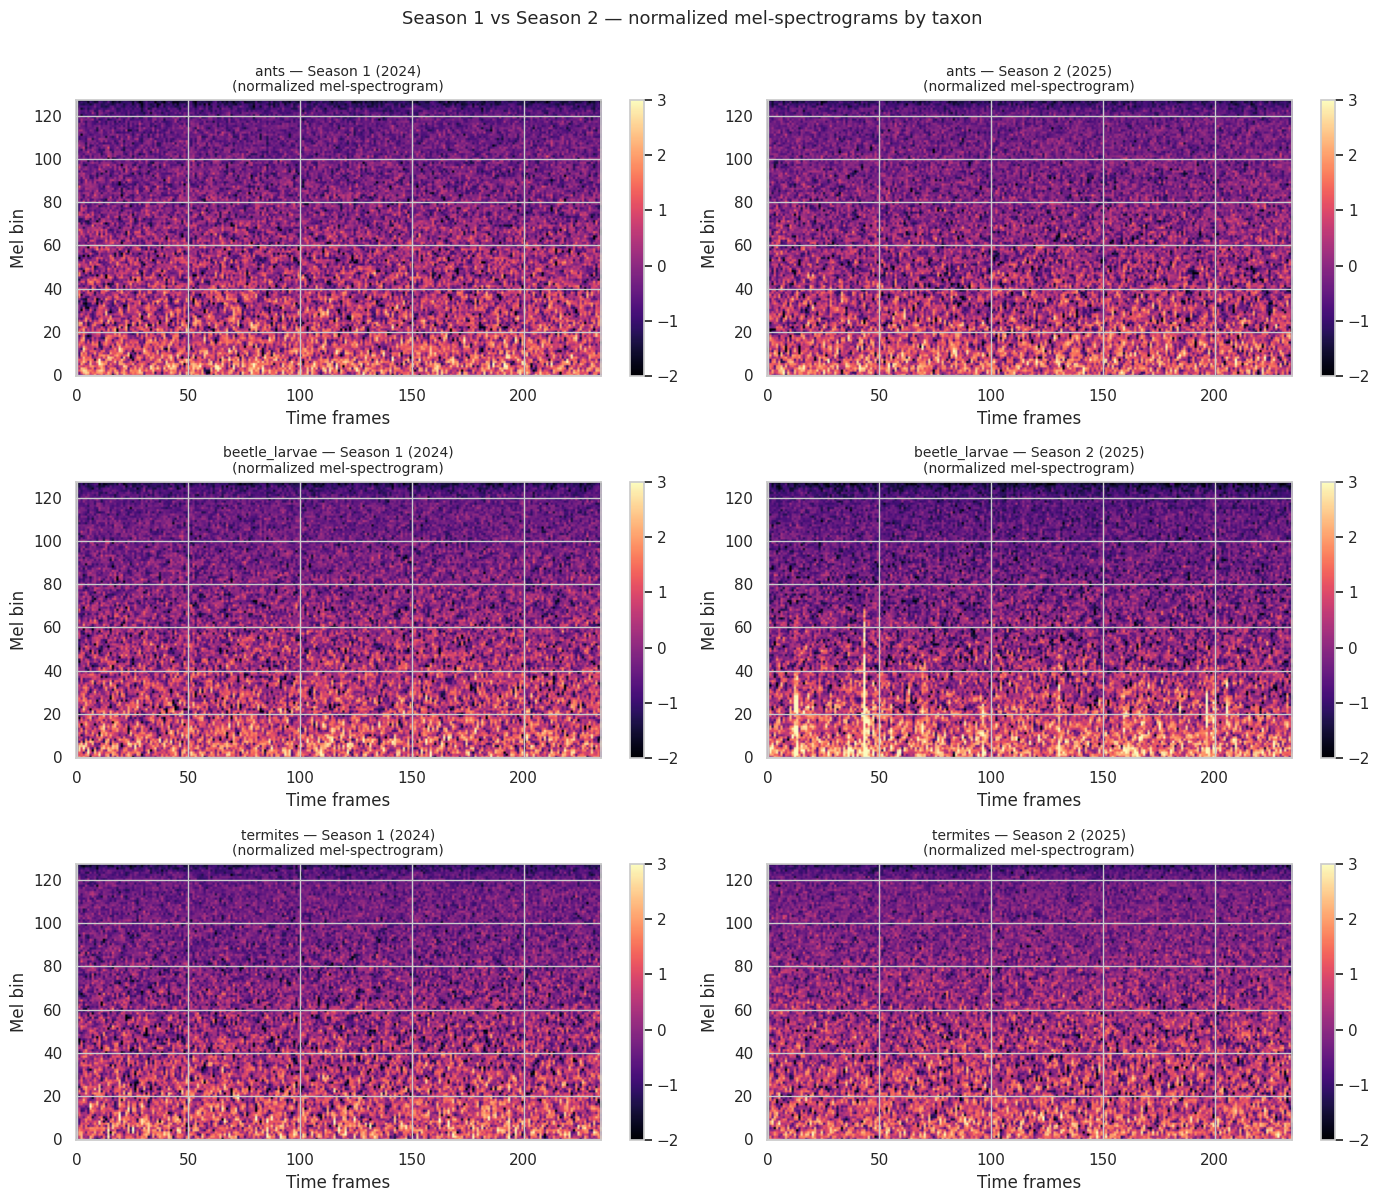

Saved comparison. Look: do same-taxon spectrograms look similar across seasons?


In [ ]:
import matplotlib.pyplot as plt
import librosa.display

manifest_s1 = pd.read_csv(SEASON1_ROOT / 'features_manifest.csv')
manifest_s2 = pd.read_csv(V3_ROOT / 'features_manifest_season2.csv')

# For each taxon, pick one season-1 and one season-2 recording, show a mid window
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for i, taxon in enumerate(['ants', 'beetle_larvae', 'termites']):
    for j, (mani, fdir, season) in enumerate([
        (manifest_s1, V1_FEATURES_DIR, 'Season 1 (2024)'),
        (manifest_s2, V3_FEATURES_S2_DIR, 'Season 2 (2025)')]):
        sub = mani[mani['taxon'] == taxon]
        row = sub.sample(1, random_state=7).iloc[0]
        feats = np.load(fdir / row['feature_filename'])['features']
        mid = feats[len(feats)//2]  # middle window, already normalized
        im = axes[i, j].imshow(mid, aspect='auto', origin='lower', cmap='magma',
                                vmin=-2, vmax=3)
        axes[i, j].set_title(f"{taxon} — {season}\n(normalized mel-spectrogram)", fontsize=10)
        axes[i, j].set_xlabel('Time frames'); axes[i, j].set_ylabel('Mel bin')
        fig.colorbar(im, ax=axes[i, j], fraction=0.046)

fig.suptitle('Season 1 vs Season 2 — normalized mel-spectrograms by taxon', fontsize=13, y=1.00)
plt.tight_layout()
save_v3_figure(fig, 'season1_vs_season2_spectrograms')
plt.show()
plt.close(fig)
print("Saved comparison. Look: do same-taxon spectrograms look similar across seasons?")

## V3 Block 5: Merged Multi-Season Model (v3)

Following the generalization finding (Finding 5.5 — season-1 models collapse to
below-chance on season 2 due to a recording-condition domain shift), this block
builds a model trained on BOTH field seasons to test whether cross-campaign
training yields cross-campaign robustness.

### Part 1: Build merged 3-class dataset spec

Combines season 1 (2024) and season 2 (2025) into a single 3-class dataset
(ants, termites, beetle larvae; control excluded), tagged with a `season`
column for season-aware splitting and per-season evaluation.

**Key design decisions for v3:**
- **Per-recording normalization** (not global): each recording is normalized to
  its own mean/std at load time. This neutralizes the ~2.2x loudness/gain
  difference between seasons (Finding 5.5), preventing the model from using
  overall energy as a season/class shortcut. Mathematically equivalent to
  re-extracting from raw dB, so existing feature files are reused (no
  re-extraction needed).
- **Both seasons in the test set**: so v3 performance can be reported per-season,
  demonstrating (or not) cross-campaign robustness.
- **Balanced training**: the merged set is ant-heavy (season 2 dominates);
  balancing strategy decided after inspecting the composition here.

**Output:** `merged_dataset_3class.csv` — the unified recording list with season
labels, feature-file paths, and taxa.

In [ ]:
# =============================================================================
# V3 Block 5 (Part 1): Merge season 1 + season 2 into unified 3-class dataset
# =============================================================================
print("=" * 70)
print("V3 Block 5.1: Build merged 3-class dataset spec")
print("=" * 70)

# --- Season 1: build a manifest-like frame pointing at season-1 features ---
manifest_s1 = pd.read_csv(SEASON1_ROOT / 'features_manifest.csv')
# season 1 manifest columns include feature_filename, taxon, count, day, batch, replicate_id
s1 = manifest_s1.copy()
s1['season'] = 1
s1['features_dir'] = str(V1_FEATURES_DIR)
# Standardize columns we need
s1_cols = s1[['feature_filename', 'taxon', 'count', 'day', 'batch', 'season', 'features_dir']].copy()

# --- Season 2 ---
manifest_s2 = pd.read_csv(V3_ROOT / 'features_manifest_season2.csv')
s2 = manifest_s2.copy()
s2['season'] = 2
s2['features_dir'] = str(V3_FEATURES_S2_DIR)
s2_cols = s2[['feature_filename', 'taxon', 'count', 'day', 'batch', 'season', 'features_dir']].copy()

# --- Combine, restrict to 3 classes ---
merged = pd.concat([s1_cols, s2_cols], ignore_index=True)
merged = merged[merged['taxon'].isin(CLASSES_3)].reset_index(drop=True)

print(f"Merged 3-class recordings: {len(merged)}")
print()
print("By season and taxon:")
pivot = merged.groupby(['season', 'taxon']).size().unstack(fill_value=0)
pivot['total'] = pivot.sum(axis=1)
print(pivot)
print()
print("Overall class balance (before any balancing):")
print(merged['taxon'].value_counts())
print()

# Save merged spec
merged.to_csv(V3_ROOT / 'merged_dataset_3class.csv', index=False)
print(f"Saved: merged_dataset_3class.csv")

V3 Block 5.1: Build merged 3-class dataset spec
Merged 3-class recordings: 3757

By season and taxon:
taxon   ants  beetle_larvae  termites  total
season                                      
1        519            520       503   1542
2       1451            386       378   2215

Overall class balance (before any balancing):
taxon
ants             1970
beetle_larvae     906
termites          881
Name: count, dtype: int64

Saved: merged_dataset_3class.csv


### Part 2: Balanced, season-aware, leakage-safe splits for v3

Creates train/val/test splits for the merged dataset with three properties:
- **Leakage-safe:** split at the session level — all recordings from one session
  stay in one split (same discipline as v1/v2).
- **Season-aware:** both seasons appear in train, val, AND test, so v3 can be
  evaluated per-season to test cross-campaign robustness.
- **Balanced:** ants (52% of the merged set, mostly from season 2) are
  downsampled to ~match the other classes, drawing proportionally from both
  seasons to prevent the model learning "season-2 signature = ant".

Split ratio 70/15/15, stratified by (season × taxon). Random seed 42.

**Outputs:** `splits_v3.csv` (session-level assignments) and a per-split,
per-season, per-taxon summary.

In [ ]:
# =============================================================================
# V3 Block 5.2: Balanced, season-aware, session-level splits
# =============================================================================
import random
random.seed(42)
np.random.seed(42)

merged = pd.read_csv(V3_ROOT / 'merged_dataset_3class.csv')

# =============================================================================
# Step 1: Define session identity (season-aware)
# =============================================================================
# A session = unique (season, day, batch, taxon, count). We don't have
# replicate_id uniformly across seasons, so use these fields. Recordings sharing
# these are one session and must stay together.
session_cols = ['season', 'day', 'batch', 'taxon', 'count']
merged['session_id'] = merged[session_cols].astype(str).agg('_'.join, axis=1)

n_sessions = merged['session_id'].nunique()
print(f"Total sessions: {n_sessions}")
print(f"Total recordings: {len(merged)}")
print()

# =============================================================================
# Step 2: Downsample ants (proportionally across seasons) BEFORE splitting
# =============================================================================
# Target ant count ~= beetle larvae count for balance
target_ants = merged[merged['taxon'] == 'beetle_larvae'].shape[0]  # ~906
print(f"Target ant recordings after downsampling: ~{target_ants}")

ants = merged[merged['taxon'] == 'ants']
non_ants = merged[merged['taxon'] != 'ants']

# Downsample ants proportionally by season
ant_keep = []
for season in [1, 2]:
    season_ants = ants[ants['season'] == season]
    frac = target_ants / len(ants)
    n_keep = int(round(len(season_ants) * frac))
    kept = season_ants.sample(n=n_keep, random_state=42)
    ant_keep.append(kept)
    print(f"  Season {season}: {len(season_ants)} ants → keep {n_keep}")
ants_down = pd.concat(ant_keep, ignore_index=True)

balanced = pd.concat([ants_down, non_ants], ignore_index=True)
print(f"\nBalanced dataset: {len(balanced)} recordings")
print(balanced['taxon'].value_counts())
print()

# =============================================================================
# Step 3: Session-level split, stratified by (season, taxon)
# =============================================================================
# Build a per-session table with its stratum
session_info = (balanced.groupby('session_id')
                .agg(season=('season', 'first'), taxon=('taxon', 'first'),
                     n_records=('feature_filename', 'count'))
                .reset_index())
session_info['stratum'] = session_info['season'].astype(str) + '_' + session_info['taxon']

print(f"Sessions after balancing: {len(session_info)}")
print("Sessions per stratum:")
print(session_info['stratum'].value_counts().sort_index())
print()

# Assign splits within each stratum
def assign_splits(group, train=0.70, val=0.15, seed=42):
    g = group.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    n = len(g)
    n_train = int(round(n * train))
    n_val = int(round(n * val))
    splits = (['train']*n_train + ['val']*n_val + ['test']*(n - n_train - n_val))
    g['split'] = splits[:n]
    return g

split_assignments = (session_info.groupby('stratum', group_keys=False)
                     .apply(assign_splits))

# Map splits back to recordings
session_to_split = dict(zip(split_assignments['session_id'], split_assignments['split']))
balanced['split'] = balanced['session_id'].map(session_to_split)

# =============================================================================
# Step 4: Verify — per split, per season, per taxon
# =============================================================================
print("=" * 70)
print("Split composition (recordings)")
print("=" * 70)
for split in ['train', 'val', 'test']:
    sub = balanced[balanced['split'] == split]
    print(f"\n{split.upper()} — {len(sub)} recordings:")
    print(sub.groupby(['season', 'taxon']).size().unstack(fill_value=0))

# Critical check: does TEST contain both seasons for all taxa?
print("\n" + "=" * 70)
print("CRITICAL CHECK: test set season coverage")
print("=" * 70)
test = balanced[balanced['split'] == 'test']
test_check = test.groupby(['season', 'taxon']).size().unstack(fill_value=0)
print(test_check)
both_seasons_ok = (test['season'].nunique() == 2)
print(f"\nTest set contains both seasons: {both_seasons_ok}")

# =============================================================================
# Step 5: Save
# =============================================================================
balanced.to_csv(V3_ROOT / 'splits_v3.csv', index=False)
print(f"\nSaved: splits_v3.csv ({len(balanced)} recordings)")

Total sessions: 95
Total recordings: 3757

Target ant recordings after downsampling: ~906
  Season 1: 519 ants → keep 239
  Season 2: 1451 ants → keep 667

Balanced dataset: 2693 recordings
taxon
ants             906
beetle_larvae    906
termites         881
Name: count, dtype: int64

Sessions after balancing: 95
Sessions per stratum:
stratum
1_ants             17
1_beetle_larvae    20
1_termites         17
2_ants             26
2_beetle_larvae     6
2_termites          9
Name: count, dtype: int64

Split composition (recordings)

TRAIN — 1839 recordings:
taxon   ants  beetle_larvae  termites
season                               
1        163            379       335
2        488            179       295

VAL — 512 recordings:
taxon   ants  beetle_larvae  termites
season                               
1         46             70        95
2         89            182        30

TEST — 342 recordings:
taxon   ants  beetle_larvae  termites
season                               
1         30

/tmp/ipykernel_869/848007210.py:76: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(assign_splits))


### Part 3: Train v3 CNN (per-recording normalization, both seasons)

Trains the same VGG-style CNN architecture as v1/v2 on the balanced, merged
two-season dataset, with per-recording normalization applied at load time.

- **Per-recording normalization:** each recording's features are re-normalized to
  its own mean/std when loaded — neutralizing the cross-season loudness/gain
  difference (Finding 5.5) so the model learns taxon features, not recording
  level. Verified mathematically equivalent to re-extracting from raw dB, so the
  existing globally-normalized feature files are reused.
- **Architecture/hyperparameters:** identical to v1/v2 (4 conv blocks, GAP,
  dropout 0.5; Adam lr=1e-3, batch 64, class weights, ReduceLROnPlateau, early
  stopping patience 8, seed 42) — so v3 is comparable to the earlier models.
- **Runtime:** High-RAM required for the RAM preload.

**Output:** `cnn_3class_v3_best.pt` + `cnn_3class_v3_history.json` in v3_fulldata/.

In [ ]:
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
import psutil

print("=" * 70)
print("V3 Block 5.3a: Preload merged features with per-recording normalization")
print("=" * 70)

torch.manual_seed(42); np.random.seed(42)

ram_gb = psutil.virtual_memory().available / 1e9
print(f"RAM available: {ram_gb:.1f} GB")
if ram_gb < 25:
    print("⚠️  Low RAM — switch to High-RAM runtime before preloading.")
    raise RuntimeError("Need High-RAM runtime")

splits_v3 = pd.read_csv(V3_ROOT / 'splits_v3.csv')

def per_recording_normalize(feats):
    """Normalize a recording's features to its own mean/std.
    feats: (n_windows, n_mels, n_frames). Neutralizes overall level."""
    m = feats.mean()
    s = feats.std()
    if s < 1e-8:
        s = 1.0
    return ((feats - m) / s).astype(np.float32)

def preload_v3_split(split_name):
    sub = splits_v3[splits_v3['split'] == split_name]
    total_windows = 0
    # First pass: count windows (need n_windows; recompute by loading shapes is slow,
    # so load once and store)
    feats_list, labels_list = [], []
    for _, row in tqdm(sub.iterrows(), total=len(sub), desc=f"  {split_name}", leave=False):
        fdir = Path(row['features_dir'])
        data = np.load(fdir / row['feature_filename'])
        feats = data['features']  # globally-normalized
        feats = per_recording_normalize(feats)  # re-normalize per recording
        feats_list.append(feats)
        labels_list.append(np.full(len(feats), CLASS_TO_IDX[row['taxon']], dtype=np.int64))
    X = np.concatenate(feats_list, axis=0)
    y = np.concatenate(labels_list, axis=0)
    print(f"  {split_name}: {len(sub)} recordings, {len(y):,} windows, {X.nbytes/1e9:.2f} GB")
    return X, y

print("Preloading train...")
X_train, y_train = preload_v3_split('train')
print("Preloading val...")
X_val, y_val = preload_v3_split('val')
print(f"\nRAM used: {psutil.virtual_memory().used/1e9:.1f} GB, "
      f"available: {psutil.virtual_memory().available/1e9:.1f} GB")

V3 Block 5.3a: Preload merged features with per-recording normalization
RAM available: 51.8 GB
Preloading train...


  train: 1839 recordings, 157,263 windows, 18.92 GB
Preloading val...


  val: 512 recordings, 42,079 windows, 5.06 GB

RAM used: 40.3 GB, available: 13.9 GB


In [ ]:
# =============================================================================
# V3 Block 5.3b: Train v3 CNN
# =============================================================================
class InMemoryWindowDataset(Dataset):
    def __init__(self, X, y): self.X, self.y = X, y
    def __len__(self): return len(self.y)
    def __getitem__(self, i):
        return torch.from_numpy(self.X[i][np.newaxis]), int(self.y[i])

BATCH_SIZE = 64
train_loader = DataLoader(InMemoryWindowDataset(X_train, y_train), batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=4, pin_memory=True, drop_last=True)
val_loader = DataLoader(InMemoryWindowDataset(X_val, y_val), batch_size=BATCH_SIZE,
                        shuffle=False, num_workers=4, pin_memory=True)
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

class_weights = compute_class_weight('balanced', classes=np.arange(3), y=y_train)
cw = torch.tensor(class_weights, dtype=torch.float32).to(device)
print(f"Class weights: {dict(zip(CLASSES_3, class_weights.round(3)))}")

model = SpectrogramCNN(n_classes=3).to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}\n")

def train_epoch(model, loader, crit, opt):
    model.train(); tot=0; P=[]; L=[]
    for x,y in tqdm(loader, desc='Train', leave=False):
        x,y = x.to(device,non_blocking=True), y.to(device,non_blocking=True)
        opt.zero_grad(); out=model(x); loss=crit(out,y); loss.backward(); opt.step()
        tot+=loss.item(); P.extend(out.argmax(1).cpu().numpy()); L.extend(y.cpu().numpy())
    return tot/len(loader), accuracy_score(L,P), f1_score(L,P,average='macro')

@torch.no_grad()
def eval_epoch(model, loader, crit):
    model.eval(); tot=0; P=[]; L=[]
    for x,y in tqdm(loader, desc='Val', leave=False):
        x,y = x.to(device,non_blocking=True), y.to(device,non_blocking=True)
        out=model(x); tot+=crit(out,y).item()
        P.extend(out.argmax(1).cpu().numpy()); L.extend(y.cpu().numpy())
    return tot/len(loader), accuracy_score(L,P), f1_score(L,P,average='macro')

crit = nn.CrossEntropyLoss(weight=cw)
opt = optim.Adam(model.parameters(), lr=1e-3)
sched = ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=4)

MODEL_PATH = V3_ROOT / 'cnn_3class_v3_best.pt'
HIST_PATH = V3_ROOT / 'cnn_3class_v3_history.json'
best_f1=-1; no_improve=0; history=[]
MAX_EPOCHS=50; PATIENCE=8

print("Training v3...")
t0=time.time()
for epoch in range(1, MAX_EPOCHS+1):
    te=time.time()
    tl,ta,tf = train_epoch(model, train_loader, crit, opt)
    vl,va,vf = eval_epoch(model, val_loader, crit)
    lr = opt.param_groups[0]['lr']
    history.append({'epoch':epoch,'train_loss':tl,'train_f1':tf,'val_loss':vl,
                    'val_acc':va,'val_f1':vf,'lr':lr,'time_s':time.time()-te})
    print(f"Epoch {epoch:2d}  train_f1={tf:.4f}  val_f1={vf:.4f}  val_acc={va:.4f}  "
          f"lr={lr:.1e}  ({time.time()-te:.0f}s)")
    sched.step(vf)
    if vf > best_f1:
        best_f1=vf; no_improve=0
        torch.save({'epoch':epoch,'model_state_dict':model.state_dict(),
                    'val_f1':vf,'val_acc':va}, MODEL_PATH)
        print(f"          → saved best (val_f1={vf:.4f})")
    else:
        no_improve+=1
    with open(HIST_PATH,'w') as f: json.dump(history,f,indent=2)
    if no_improve>=PATIENCE:
        print("Early stopping."); break

print(f"\nTotal: {(time.time()-t0)/60:.1f} min. Best val macro-F1: {best_f1:.4f}")

Train batches: 2457, Val batches: 658
Class weights: {'ants': np.float64(1.114), 'beetle_larvae': np.float64(0.959), 'termites': np.float64(0.943)}
Parameters: 1,174,371

Training v3...


Epoch  1  train_f1=0.5733  val_f1=0.3189  val_acc=0.3322  lr=1.0e-03  (647s)
          → saved best (val_f1=0.3189)


Epoch  2  train_f1=0.6522  val_f1=0.3197  val_acc=0.3323  lr=1.0e-03  (658s)
          → saved best (val_f1=0.3197)


Epoch  3  train_f1=0.6899  val_f1=0.3861  val_acc=0.4027  lr=1.0e-03  (659s)
          → saved best (val_f1=0.3861)


Epoch  4  train_f1=0.7155  val_f1=0.3640  val_acc=0.3690  lr=1.0e-03  (659s)


...

Epoch 12  train_f1=0.7940  val_f1=0.3922  val_acc=0.3936  lr=1.0e-03  (659s)


Epoch 13  train_f1=0.7988  val_f1=0.3681  val_acc=0.3834  lr=1.0e-03  (657s)


Epoch 14  train_f1=0.8192  val_f1=0.4065  val_acc=0.4073  lr=5.0e-04  (659s)


Epoch 15  train_f1=0.8282  val_f1=0.3969  val_acc=0.3978  lr=5.0e-04  (657s)


Epoch 16  train_f1=0.8329  val_f1=0.3754  val_acc=0.3785  lr=5.0e-04  (657s)
Early stopping.

Total: 175.3 min. Best val macro-F1: 0.4351


### Part 4: Per-season evaluation of the v3 model

Evaluates the trained v3 model on the held-out test set, broken down BY SEASON,
to answer the core question: does a model trained on both campaigns work on both
campaigns? Uses the same per-recording normalization as training, and
recording-level mean-probability aggregation.

Reports: overall test performance; per-season performance (season 1 vs season 2,
the key comparison); and per-season-per-class detail (interpreted cautiously
where test cells are small).

In [ ]:
# =============================================================================
# V3 Block 5.4: Per-season evaluation of v3 model
# =============================================================================
print("=" * 70)
print("V3 Block 5.4: Per-season test evaluation")
print("=" * 70)

splits_v3 = pd.read_csv(V3_ROOT / 'splits_v3.csv')
test = splits_v3[splits_v3['split'] == 'test'].reset_index(drop=True)
print(f"Test recordings: {len(test)} "
      f"(season 1: {sum(test.season==1)}, season 2: {sum(test.season==2)})")

# Load v3 model
model = SpectrogramCNN(n_classes=3).to(device)
ckpt = torch.load(V3_ROOT / 'cnn_3class_v3_best.pt', map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f"Loaded v3 (epoch {ckpt['epoch']}, val_f1={ckpt['val_f1']:.4f})\n")

def per_recording_normalize(feats):
    m, s = feats.mean(), feats.std()
    return ((feats - m) / (s if s > 1e-8 else 1.0)).astype(np.float32)

# Recording-level inference with season tracking
rec_rows = []
with torch.no_grad():
    for _, row in tqdm(test.iterrows(), total=len(test), desc="Inference"):
        fdir = Path(row['features_dir'])
        feats = np.load(fdir / row['feature_filename'])['features']
        feats = per_recording_normalize(feats)
        X = torch.from_numpy(feats[:, np.newaxis, :, :].astype(np.float32)).to(device)
        mean_probs = torch.softmax(model(X), dim=1).cpu().numpy().mean(axis=0)
        rec_rows.append({
            'season': row['season'], 'true_label': CLASS_TO_IDX[row['taxon']],
            'pred_label': int(np.argmax(mean_probs)),
        })
rec = pd.DataFrame(rec_rows)

# --- Overall ---
def metrics(df, label):
    acc = accuracy_score(df['true_label'], df['pred_label'])
    f1 = f1_score(df['true_label'], df['pred_label'], average='macro')
    print(f"\n{label}: accuracy={acc:.4f}, macro-F1={f1:.4f}  (n={len(df)})")
    cm = confusion_matrix(df['true_label'], df['pred_label'], labels=[0,1,2])
    cmdf = pd.DataFrame(cm, index=CLASSES_3, columns=CLASSES_3)
    cmdf.index.name='True'; cmdf.columns.name='Pred'
    print(cmdf.to_string())
    return acc, f1

print("=" * 70)
print("OVERALL (both seasons)")
print("=" * 70)
metrics(rec, "Overall test")

print("\n" + "=" * 70)
print("PER-SEASON (the key comparison)")
print("=" * 70)
for s in [1, 2]:
    metrics(rec[rec['season'] == s], f"Season {s} test")

# --- Comparison to the single-season generalization collapse ---
print("\n" + "=" * 70)
print("CONTEXT: v3 season-2 vs the single-season collapse")
print("=" * 70)
s2 = rec[rec['season'] == 2]
s2_acc = accuracy_score(s2['true_label'], s2['pred_label'])
print(f"v1/v2 (season-1-only) on season 2:  ~22-24% accuracy (Finding 5.5)")
print(f"v3 (both seasons) on season-2 test: {s2_acc:.1%} accuracy")
print(f"→ {'IMPROVED' if s2_acc > 0.30 else 'still weak'}")

# Save
rec.to_csv(V3_ROOT / 'v3_test_predictions.csv', index=False)
with open(V3_ROOT / 'v3_eval_results.json', 'w') as f:
    json.dump({
        'overall_acc': float(accuracy_score(rec['true_label'], rec['pred_label'])),
        'overall_f1': float(f1_score(rec['true_label'], rec['pred_label'], average='macro')),
        'season1_acc': float(accuracy_score(rec[rec.season==1]['true_label'], rec[rec.season==1]['pred_label'])),
        'season2_acc': float(accuracy_score(rec[rec.season==2]['true_label'], rec[rec.season==2]['pred_label'])),
    }, f, indent=2)
print(f"\nSaved: v3_test_predictions.csv + v3_eval_results.json")

V3 Block 5.4: Per-season test evaluation
Test recordings: 342 (season 1: 174, season 2: 168)
Loaded v3 (epoch 8, val_f1=0.4351)



Inference: 100%|██████████| 342/342 [06:26<00:00,  1.13s/it]

OVERALL (both seasons)

Overall test: accuracy=0.5585, macro-F1=0.5351  (n=342)
Pred           ants  beetle_larvae  termites
True                                        
ants             83             22        15
beetle_larvae     4             82        10
termites         69             31        26

PER-SEASON (the key comparison)

Season 1 test: accuracy=0.5977, macro-F1=0.5669  (n=174)
Pred           ants  beetle_larvae  termites
True                                        
ants             20              1         9
beetle_larvae     2             61         8
termites         24             26        23

Season 2 test: accuracy=0.5179, macro-F1=0.4357  (n=168)
Pred           ants  beetle_larvae  termites
True                                        
ants             63             21         6
beetle_larvae     2             21         2
termites         45              5         3

CONTEXT: v3 season-2 vs the single-season collapse
v1/v2 (season-1-only) on season 2:  ~22-24% 

### Part 5: v3 with global normalization (comparison experiment)

Tests the hypothesis that overall loudness carries useful biological signal
(more active organisms = louder) which per-recording normalization discarded.
Retrains v3 identically EXCEPT using global normalization recomputed over the
merged (both-season) training set, so the model can use overall-energy cues.

This is a controlled experiment: same splits, same architecture, same
hyperparameters as the per-recording v3 — only the normalization differs. Saved
as a separate model so both can be compared.

**Verification plan (Part 6):** a higher overall number alone is NOT accepted as
success, because global norm reintroduces the season-correlated loudness
difference (season 2 is ~2.2x louder AND 63% ants), which the model could
exploit as a "louder → ant" shortcut. We verify genuine learning by checking
(a) whether both seasons improve, and (b) whether the season-2 termite→ant
confusion is fixed (genuine) or worsened (shortcut).

**Outputs:** `cnn_3class_v3_globalnorm_best.pt`, `..._history.json`,
merged global-norm stats saved for the record.

In [ ]:
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
import psutil

print("=" * 70)
print("V3 Block 5.5a: Compute merged global norm + preload")
print("=" * 70)

torch.manual_seed(42); np.random.seed(42)

ram_gb = psutil.virtual_memory().available / 1e9
print(f"RAM available: {ram_gb:.1f} GB")
if ram_gb < 25:
    raise RuntimeError("Need High-RAM runtime")

splits_v3 = pd.read_csv(V3_ROOT / 'splits_v3.csv')

# =============================================================================
# Step 1: Recompute GLOBAL normalization over the MERGED TRAIN set only
# =============================================================================
# IMPORTANT: stats computed on TRAIN ONLY (never val/test) to avoid leakage.
# Our existing .npz features are already globally-normalized with season-1 stats
# (mean GM_s1, std GS_s1). To get "raw-dB-equivalent" values we invert that,
# then compute fresh merged stats. Inversion: db_equiv = feat * GS_s1 + GM_s1.
with open(SEASON1_ROOT / 'pipeline_params_v3.json') as f:
    P = json.load(f)
GM_s1 = P['global_mean']; GS_s1 = P['global_std']

train_rows = splits_v3[splits_v3['split'] == 'train']
print(f"Computing merged global stats over {len(train_rows)} train recordings (train only)...")

# Streaming mean/std (Welford-ish via sum and sumsq) over db-equivalent values
total_n = 0
total_sum = 0.0
total_sumsq = 0.0
for _, row in tqdm(train_rows.iterrows(), total=len(train_rows), desc="  stats"):
    fdir = Path(row['features_dir'])
    feats = np.load(fdir / row['feature_filename'])['features']  # season-1-global-normed
    db_equiv = feats.astype(np.float64) * GS_s1 + GM_s1  # invert to raw dB
    total_n += db_equiv.size
    total_sum += db_equiv.sum()
    total_sumsq += (db_equiv ** 2).sum()

merged_mean = total_sum / total_n
merged_std = np.sqrt(total_sumsq / total_n - merged_mean ** 2)
print(f"\nMerged global normalization (train only):")
print(f"  mean = {merged_mean:.4f}  (season-1-only was {GM_s1:.4f})")
print(f"  std  = {merged_std:.4f}  (season-1-only was {GS_s1:.4f})")

# Save the merged stats
with open(V3_ROOT / 'merged_global_norm_stats.json', 'w') as f:
    json.dump({'merged_mean': float(merged_mean), 'merged_std': float(merged_std),
               'season1_mean': GM_s1, 'season1_std': GS_s1,
               'computed_on': 'v3 merged train split only'}, f, indent=2)
print(f"Saved: merged_global_norm_stats.json\n")

# =============================================================================
# Step 2: Preload with MERGED GLOBAL normalization
# =============================================================================
def to_merged_global(feats):
    """Convert season-1-global-normed features to merged-global-normed.
    Invert season-1 norm to dB, then apply merged norm."""
    db_equiv = feats.astype(np.float32) * GS_s1 + GM_s1
    return ((db_equiv - merged_mean) / merged_std).astype(np.float32)

def preload_split(split_name):
    sub = splits_v3[splits_v3['split'] == split_name]
    feats_list, labels_list = [], []
    for _, row in tqdm(sub.iterrows(), total=len(sub), desc=f"  {split_name}", leave=False):
        fdir = Path(row['features_dir'])
        feats = np.load(fdir / row['feature_filename'])['features']
        feats = to_merged_global(feats)
        feats_list.append(feats)
        labels_list.append(np.full(len(feats), CLASS_TO_IDX[row['taxon']], dtype=np.int64))
    X = np.concatenate(feats_list, axis=0)
    y = np.concatenate(labels_list, axis=0)
    print(f"  {split_name}: {len(sub)} recs, {len(y):,} windows, {X.nbytes/1e9:.2f} GB")
    return X, y

print("Preloading train (merged global norm)...")
X_train, y_train = preload_split('train')
print("Preloading val (merged global norm)...")
X_val, y_val = preload_split('val')
print(f"\nRAM used: {psutil.virtual_memory().used/1e9:.1f} GB")

V3 Block 5.5a: Compute merged global norm + preload
RAM available: 52.2 GB
Computing merged global stats over 1839 train recordings (train only)...


  stats: 100%|██████████| 1839/1839 [33:10<00:00,  1.08s/it]



Merged global normalization (train only):
  mean = -40.7700  (season-1-only was -41.3738)
  std  = 5.0339  (season-1-only was 4.5084)
Saved: merged_global_norm_stats.json

Preloading train (merged global norm)...


  train: 1839 recs, 157,263 windows, 18.92 GB
Preloading val (merged global norm)...


  val: 512 recs, 42,079 windows, 5.06 GB

RAM used: 45.1 GB


In [ ]:
# =============================================================================
# V3 Block 5.5b: Train v3 global-norm model
# =============================================================================
class InMemoryWindowDataset(Dataset):
    def __init__(self, X, y): self.X, self.y = X, y
    def __len__(self): return len(self.y)
    def __getitem__(self, i):
        return torch.from_numpy(self.X[i][np.newaxis]), int(self.y[i])

BATCH_SIZE = 64
train_loader = DataLoader(InMemoryWindowDataset(X_train, y_train), batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=4, pin_memory=True, drop_last=True)
val_loader = DataLoader(InMemoryWindowDataset(X_val, y_val), batch_size=BATCH_SIZE,
                        shuffle=False, num_workers=4, pin_memory=True)
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

class_weights = compute_class_weight('balanced', classes=np.arange(3), y=y_train)
cw = torch.tensor(class_weights, dtype=torch.float32).to(device)
print(f"Class weights: {dict(zip(CLASSES_3, class_weights.round(3)))}")

model = SpectrogramCNN(n_classes=3).to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}\n")

def train_epoch(model, loader, crit, opt):
    model.train(); tot=0; Pr=[]; L=[]
    for x,y in tqdm(loader, desc='Train', leave=False):
        x,y = x.to(device,non_blocking=True), y.to(device,non_blocking=True)
        opt.zero_grad(); out=model(x); loss=crit(out,y); loss.backward(); opt.step()
        tot+=loss.item(); Pr.extend(out.argmax(1).cpu().numpy()); L.extend(y.cpu().numpy())
    return tot/len(loader), accuracy_score(L,Pr), f1_score(L,Pr,average='macro')

@torch.no_grad()
def eval_epoch(model, loader, crit):
    model.eval(); tot=0; Pr=[]; L=[]
    for x,y in tqdm(loader, desc='Val', leave=False):
        x,y = x.to(device,non_blocking=True), y.to(device,non_blocking=True)
        out=model(x); tot+=crit(out,y).item()
        Pr.extend(out.argmax(1).cpu().numpy()); L.extend(y.cpu().numpy())
    return tot/len(loader), accuracy_score(L,Pr), f1_score(L,Pr,average='macro')

crit = nn.CrossEntropyLoss(weight=cw)
opt = optim.Adam(model.parameters(), lr=1e-3)
sched = ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=4)

MODEL_PATH = V3_ROOT / 'cnn_3class_v3_globalnorm_best.pt'
HIST_PATH = V3_ROOT / 'cnn_3class_v3_globalnorm_history.json'
best_f1=-1; no_improve=0; history=[]; MAX_EPOCHS=50; PATIENCE=8

print("Training v3 (global norm)...")
t0=time.time()
for epoch in range(1, MAX_EPOCHS+1):
    te=time.time()
    tl,ta,tf = train_epoch(model, train_loader, crit, opt)
    vl,va,vf = eval_epoch(model, val_loader, crit)
    lr = opt.param_groups[0]['lr']
    history.append({'epoch':epoch,'train_loss':tl,'train_f1':tf,'val_loss':vl,
                    'val_acc':va,'val_f1':vf,'lr':lr,'time_s':time.time()-te})
    print(f"Epoch {epoch:2d}  train_f1={tf:.4f}  val_f1={vf:.4f}  val_acc={va:.4f}  "
          f"lr={lr:.1e}  ({time.time()-te:.0f}s)")
    sched.step(vf)
    if vf > best_f1:
        best_f1=vf; no_improve=0
        torch.save({'epoch':epoch,'model_state_dict':model.state_dict(),
                    'val_f1':vf,'val_acc':va}, MODEL_PATH)
        print(f"          → saved best (val_f1={vf:.4f})")
    else:
        no_improve+=1
    with open(HIST_PATH,'w') as f: json.dump(history,f,indent=2)
    if no_improve>=PATIENCE:
        print("Early stopping."); break

print(f"\nTotal: {(time.time()-t0)/60:.1f} min. Best val macro-F1: {best_f1:.4f}")

Train batches: 2457, Val batches: 658
Class weights: {'ants': np.float64(1.114), 'beetle_larvae': np.float64(0.959), 'termites': np.float64(0.943)}
Parameters: 1,174,371

Training v3 (global norm)...


Epoch  1  train_f1=0.5962  val_f1=0.4197  val_acc=0.4371  lr=1.0e-03  (603s)
          → saved best (val_f1=0.4197)


Epoch  2  train_f1=0.6693  val_f1=0.4132  val_acc=0.4258  lr=1.0e-03  (611s)


Epoch  3  train_f1=0.7013  val_f1=0.3166  val_acc=0.3489  lr=1.0e-03  (613s)


Epoch  4  train_f1=0.7223  val_f1=0.3518  val_acc=0.3636  lr=1.0e-03  (611s)


Epoch  5  train_f1=0.7381  val_f1=0.3663  val_acc=0.3779  lr=1.0e-03  (609s)


Epoch  6  train_f1=0.7473  val_f1=0.3568  val_acc=0.3709  lr=1.0e-03  (609s)


Epoch  7  train_f1=0.7665  val_f1=0.3769  val_acc=0.3775  lr=5.0e-04  (609s)


Epoch  8  train_f1=0.7735  val_f1=0.3921  val_acc=0.3934  lr=5.0e-04  (609s)


Epoch  9  train_f1=0.7781  val_f1=0.3694  val_acc=0.3740  lr=5.0e-04  (610s)
Early stopping.

Total: 91.4 min. Best val macro-F1: 0.4197


### Part 6: Verification — global-norm vs per-recording, is the gain real or a shortcut?

In [ ]:
# =============================================================================
# V3 Block 5.6: Verify whether global norm learned genuinely or via shortcut
# =============================================================================
print("=" * 70)
print("V3 Block 5.6: Global-norm vs per-recording — verification")
print("=" * 70)

splits_v3 = pd.read_csv(V3_ROOT / 'splits_v3.csv')
test = splits_v3[splits_v3['split'] == 'test'].reset_index(drop=True)

with open(SEASON1_ROOT / 'pipeline_params_v3.json') as f:
    P = json.load(f)
GM_s1=P['global_mean']; GS_s1=P['global_std']
with open(V3_ROOT / 'merged_global_norm_stats.json') as f:
    ms = json.load(f)
merged_mean, merged_std = ms['merged_mean'], ms['merged_std']

def norm_global(feats):
    db = feats.astype(np.float32)*GS_s1 + GM_s1
    return ((db - merged_mean)/merged_std).astype(np.float32)
def norm_perrec(feats):
    m,s = feats.mean(), feats.std()
    return ((feats - m)/(s if s>1e-8 else 1.0)).astype(np.float32)

def evaluate_model(model_path, norm_fn, label):
    model = SpectrogramCNN(n_classes=3).to(device)
    ckpt = torch.load(model_path, map_location=device)
    model.load_state_dict(ckpt['model_state_dict']); model.eval()
    rows=[]
    with torch.no_grad():
        for _, row in test.iterrows():
            feats = np.load(Path(row['features_dir'])/row['feature_filename'])['features']
            feats = norm_fn(feats)
            X = torch.from_numpy(feats[:,np.newaxis,:,:].astype(np.float32)).to(device)
            mp = torch.softmax(model(X),dim=1).cpu().numpy().mean(axis=0)
            rows.append({'season':row['season'],'true_label':CLASS_TO_IDX[row['taxon']],
                         'pred_label':int(np.argmax(mp))})
    return pd.DataFrame(rows)

def summarize(rec, label):
    print(f"\n{'='*60}\n{label}\n{'='*60}")
    for scope, df in [('Overall', rec), ('Season 1', rec[rec.season==1]),
                      ('Season 2', rec[rec.season==2])]:
        acc=accuracy_score(df.true_label,df.pred_label)
        f1=f1_score(df.true_label,df.pred_label,average='macro')
        print(f"  {scope:10s}: acc={acc:.4f}  macro-F1={f1:.4f}  (n={len(df)})")
    # Season-2 termite->ant shortcut check
    s2 = rec[rec.season==2]
    s2_term = s2[s2.true_label==CLASS_TO_IDX['termites']]
    term_as_ant = (s2_term.pred_label==CLASS_TO_IDX['ants']).sum()
    print(f"  [shortcut check] season-2 termites → ant: {term_as_ant}/{len(s2_term)}")
    return rec

print("\nEvaluating per-recording-norm v3 (existing best model)...")
rec_pr = evaluate_model(V3_ROOT/'cnn_3class_v3_best.pt', norm_perrec, "PER-RECORDING NORM")
summarize(rec_pr, "PER-RECORDING NORM v3")

print("\nEvaluating global-norm v3...")
rec_gl = evaluate_model(V3_ROOT/'cnn_3class_v3_globalnorm_best.pt', norm_global, "GLOBAL NORM")
summarize(rec_gl, "GLOBAL NORM v3")

# =============================================================================
# Verdict
# =============================================================================
print("\n" + "=" * 70)
print("VERDICT")
print("=" * 70)
def s2acc(r): return accuracy_score(r[r.season==2].true_label, r[r.season==2].pred_label)
def s1acc(r): return accuracy_score(r[r.season==1].true_label, r[r.season==1].pred_label)
def s2_term_ant(r):
    s2=r[r.season==2]; t=s2[s2.true_label==CLASS_TO_IDX['termites']]
    return (t.pred_label==CLASS_TO_IDX['ants']).sum(), len(t)

pr_ta = s2_term_ant(rec_pr); gl_ta = s2_term_ant(rec_gl)
print(f"Season 1 acc:  per-rec {s1acc(rec_pr):.3f}  →  global {s1acc(rec_gl):.3f}")
print(f"Season 2 acc:  per-rec {s2acc(rec_pr):.3f}  →  global {s2acc(rec_gl):.3f}")
print(f"S2 termite→ant: per-rec {pr_ta[0]}/{pr_ta[1]}  →  global {gl_ta[0]}/{gl_ta[1]}")
print()
print("How to read:")
print("- If global improves BOTH seasons AND reduces termite→ant → genuine learning,")
print("  loudness carried biological signal. Global norm wins.")
print("- If global improves overall but termite→ant gets WORSE (more termites called")
print("  ants) → shortcut exploitation. Per-recording norm is the honest choice.")

# Save comparison
pd.DataFrame({
    'model':['per_recording','global'],
    's1_acc':[s1acc(rec_pr), s1acc(rec_gl)],
    's2_acc':[s2acc(rec_pr), s2acc(rec_gl)],
    's2_termite_as_ant':[f"{pr_ta[0]}/{pr_ta[1]}", f"{gl_ta[0]}/{gl_ta[1]}"],
}).to_csv(V3_ROOT/'v3_norm_comparison.csv', index=False)
print("Saved: v3_norm_comparison.csv")

V3 Block 5.6: Global-norm vs per-recording — verification

Evaluating per-recording-norm v3 (existing best model)...

PER-RECORDING NORM v3
  Overall   : acc=0.5585  macro-F1=0.5351  (n=342)
  Season 1  : acc=0.5977  macro-F1=0.5669  (n=174)
  Season 2  : acc=0.5179  macro-F1=0.4357  (n=168)
  [shortcut check] season-2 termites → ant: 45/53

Evaluating global-norm v3...

GLOBAL NORM v3
  Overall   : acc=0.5029  macro-F1=0.4911  (n=342)
  Season 1  : acc=0.6437  macro-F1=0.4659  (n=174)
  Season 2  : acc=0.3571  macro-F1=0.2868  (n=168)
  [shortcut check] season-2 termites → ant: 37/53

VERDICT
Season 1 acc:  per-rec 0.598  →  global 0.644
Season 2 acc:  per-rec 0.518  →  global 0.357
S2 termite→ant: per-rec 45/53  →  global 37/53

How to read:
- If global improves BOTH seasons AND reduces termite→ant → genuine learning,
  loudness carried biological signal. Global norm wins.
- If global improves overall but termite→ant gets WORSE (more termites called
  ants) → shortcut exploitation. P